# SlotODE — Slot Trajectory Visualization

Visualizes how slot representations evolve during the ODE integration in the SlotODE model.
We load the best checkpoint, run inference with `return_traj=True`, and plot:
1. Input images, reconstructions, and per-slot masks
2. Slot mask evolution across ODE time steps
3. PCA projection of slot trajectories in latent space

In [1]:
import pickle
from pathlib import Path

import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.decomposition import PCA

from model import SlotODEModel

print(f"JAX devices: {jax.devices()}")

JAX devices: [CudaDevice(id=0)]


## 1. Load checkpoint

In [2]:
CKPT_PATH = "runs_data/slot_ode_11_slots_euler_T6_dt0.5/checkpoints/best.eqx"
META_PATH = CKPT_PATH.replace(".eqx", "_meta.pkl")

with open(META_PATH, "rb") as f:
    meta = pickle.load(f)

ckpt_args = meta["args"]
print(f"Checkpoint trained for {meta['step']:,} steps, best val loss: {meta['best_val_loss']:.6f}")
print(f"Model config: {ckpt_args}")

Checkpoint trained for 485,000 steps, best val loss: 0.000639
Model config: {'model': 'slot_ode', 'data_dir': 'CLEVR_64', 'resolution': 64, 'batch_size': 64, 'lr': 0.0004, 'warmup_steps': 10000, 'decay_steps': 100000, 'decay_rate': 0.5, 'total_steps': 500000, 'num_slots': 11, 'slot_dim': 64, 'enc_hidden_dim': 64, 'num_iter': 3, 'dt': 0.5, 'd_emb': 64, 'n_freq': 128, 'autonomous': True, 'log_every': 100, 'val_every': 5000, 'img_every': 5000, 'ckpt_every': 10000, 'ckpt_dir': 'checkpoints', 'experiment': 'slot_ode_jax', 'run_name': 'euler_T3_dt0.5', 'seed': 42, 'grad_clip': 1.0, 'resume': None, 'gcs_ckpt': None}


In [3]:
resolution = (ckpt_args["resolution"], ckpt_args["resolution"])

key = jax.random.key(0)
model = SlotODEModel(
    resolution=resolution,
    num_slots=ckpt_args["num_slots"],
    slot_dim=ckpt_args["slot_dim"],
    enc_hidden_dim=ckpt_args.get("enc_hidden_dim", 64),
    num_iter=ckpt_args["num_iter"],
    dt0=ckpt_args.get("dt", None) or 1.0,
    d_emb=ckpt_args.get("d_emb", 64),
    n_freq=ckpt_args.get("n_freq", 128),
    autonomous=ckpt_args.get("autonomous", False),
    key=key,
)

model = eqx.tree_deserialise_leaves(CKPT_PATH, model)
IS_AUTONOMOUS = ckpt_args.get("autonomous", False)
n_params = sum(p.size for p in jax.tree.leaves(eqx.filter(model, eqx.is_array)))
print(f"Loaded model: {n_params:,} parameters, autonomous={IS_AUTONOMOUS}")

Loaded model: 783,236 parameters, autonomous=True


## 2. Load sample images

In [4]:
DATA_DIR = Path("CLEVR_64")
N_SAMPLES = 4

val_imgs = sorted((DATA_DIR / "images" / "val").glob("*.png"))
np.random.seed(7)
chosen = np.random.choice(len(val_imgs), N_SAMPLES, replace=False)
chosen.sort()

images = []
for idx in chosen:
    img = np.array(Image.open(val_imgs[idx]).convert("RGB"), dtype=np.float32)
    img = img.transpose(2, 0, 1) / 127.5 - 1.0  # [3, H, W] in [-1, 1]
    images.append(img)

images_jax = jnp.array(np.stack(images))  # [B, 3, H, W]
print(f"Loaded {N_SAMPLES} images: shape {images_jax.shape}")

Loaded 4 images: shape (4, 3, 64, 64)


## 3. Forward pass with trajectory

In [5]:
NUM_TRAJ_PTS = 30

@eqx.filter_jit
def forward_with_traj(model, images, key):
    return model(images, key=key, return_traj=True)

key = jax.random.key(42)
recon, masks, slots, traj = forward_with_traj(model, images_jax, key)

print(f"Reconstruction: {recon.shape}")
print(f"Masks: {masks.shape}")
print(f"Final slots: {slots.shape}")
print(f"Trajectory: {traj.shape}  (time_pts, batch, n_slots, slot_dim)")

E0318 16:09:40.491533   31176 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


E0318 16:09:41.110992   31168 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Reconstruction: (4, 3, 64, 64)
Masks: (4, 11, 64, 64)
Final slots: (4, 11, 64)
Trajectory: (20, 4, 11, 64)  (time_pts, batch, n_slots, slot_dim)


## 4. Input / Reconstruction / Slot masks

/tmp/ipykernel_31021/4177539868.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  slot_cmap = plt.cm.get_cmap("tab20", N_slots)


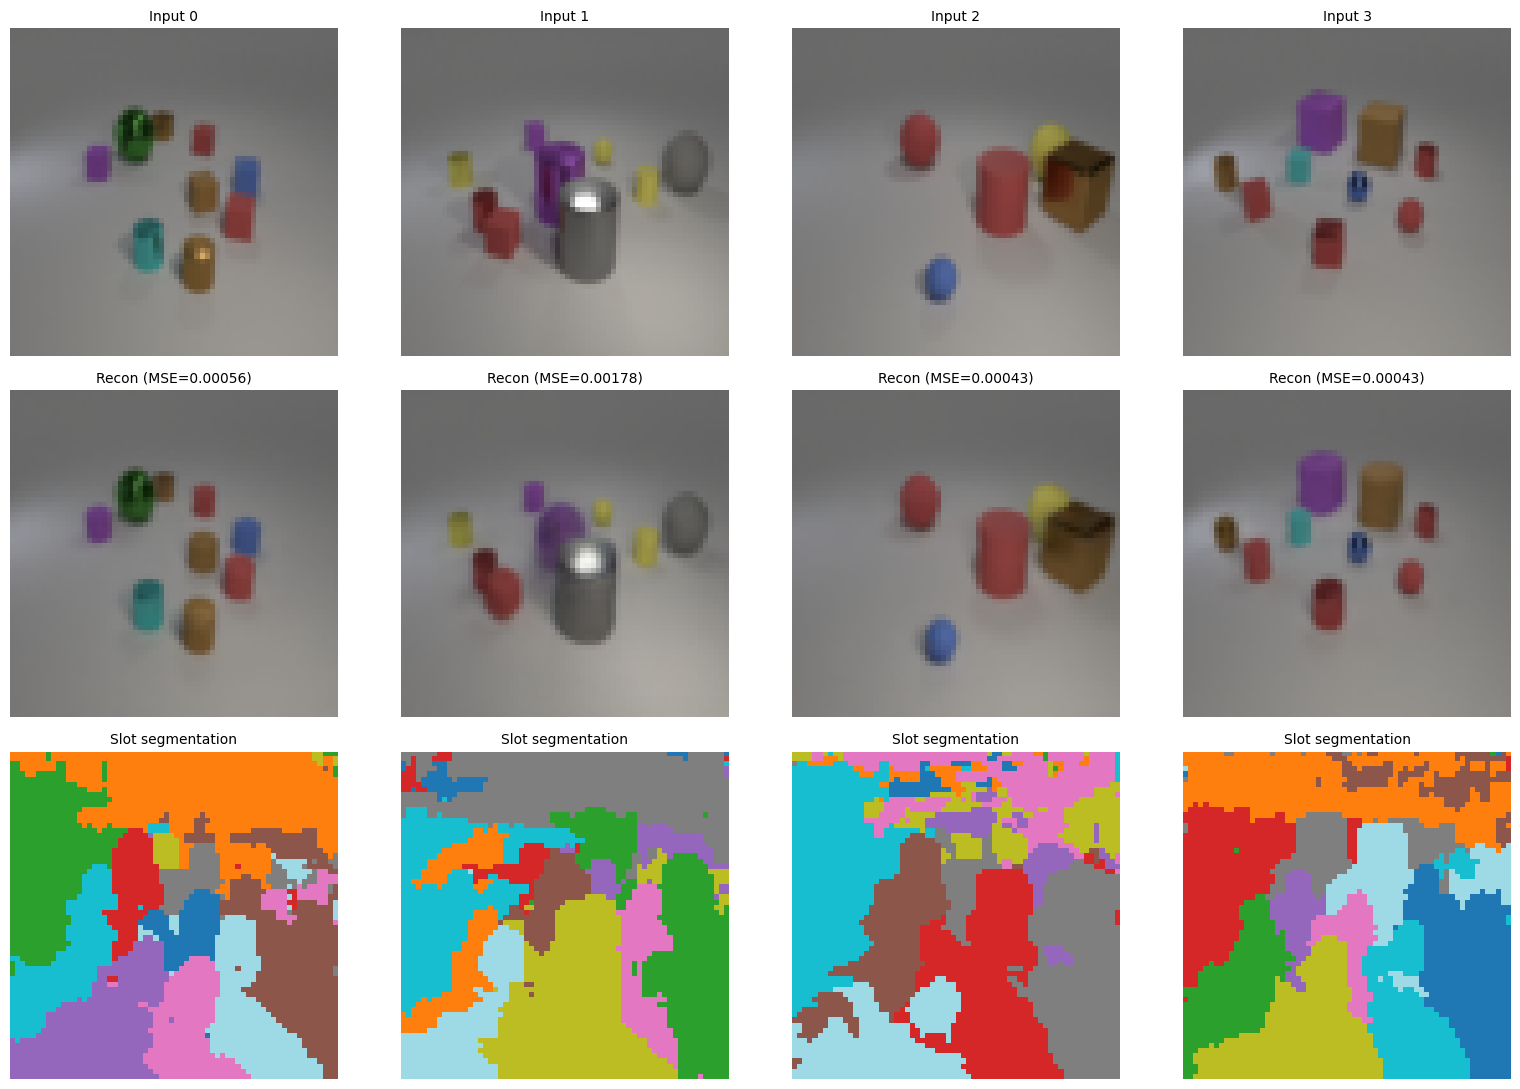

In [6]:
def to_img(t):
    """Convert [3, H, W] in [-1,1] to [H, W, 3] in [0,1]."""
    return np.clip((t.transpose(1, 2, 0) + 1) / 2, 0, 1)

recon_np = np.array(recon)
masks_np = np.array(masks)
imgs_np = np.array(images_jax)

B = imgs_np.shape[0]
N_slots = masks_np.shape[1]

slot_cmap = plt.cm.get_cmap("tab20", N_slots)
slot_colors = [slot_cmap(i)[:3] for i in range(N_slots)]

fig, axes = plt.subplots(3, B, figsize=(4 * B, 11))
if B == 1:
    axes = axes[:, None]

for j in range(B):
    axes[0, j].imshow(to_img(imgs_np[j]))
    axes[0, j].set_title(f"Input {j}", fontsize=10)
    axes[0, j].axis("off")

    axes[1, j].imshow(to_img(recon_np[j]))
    mse = float(((recon_np[j] - imgs_np[j]) ** 2).mean())
    axes[1, j].set_title(f"Recon (MSE={mse:.5f})", fontsize=10)
    axes[1, j].axis("off")

    seg = masks_np[j].argmax(axis=0)  # [H, W]
    seg_rgb = np.zeros((*seg.shape, 3))
    for s in range(N_slots):
        seg_rgb[seg == s] = slot_colors[s]
    axes[2, j].imshow(seg_rgb)
    axes[2, j].set_title("Slot segmentation", fontsize=10)
    axes[2, j].axis("off")

plt.tight_layout()
plt.show()

## 5. Per-slot mask detail (one image)

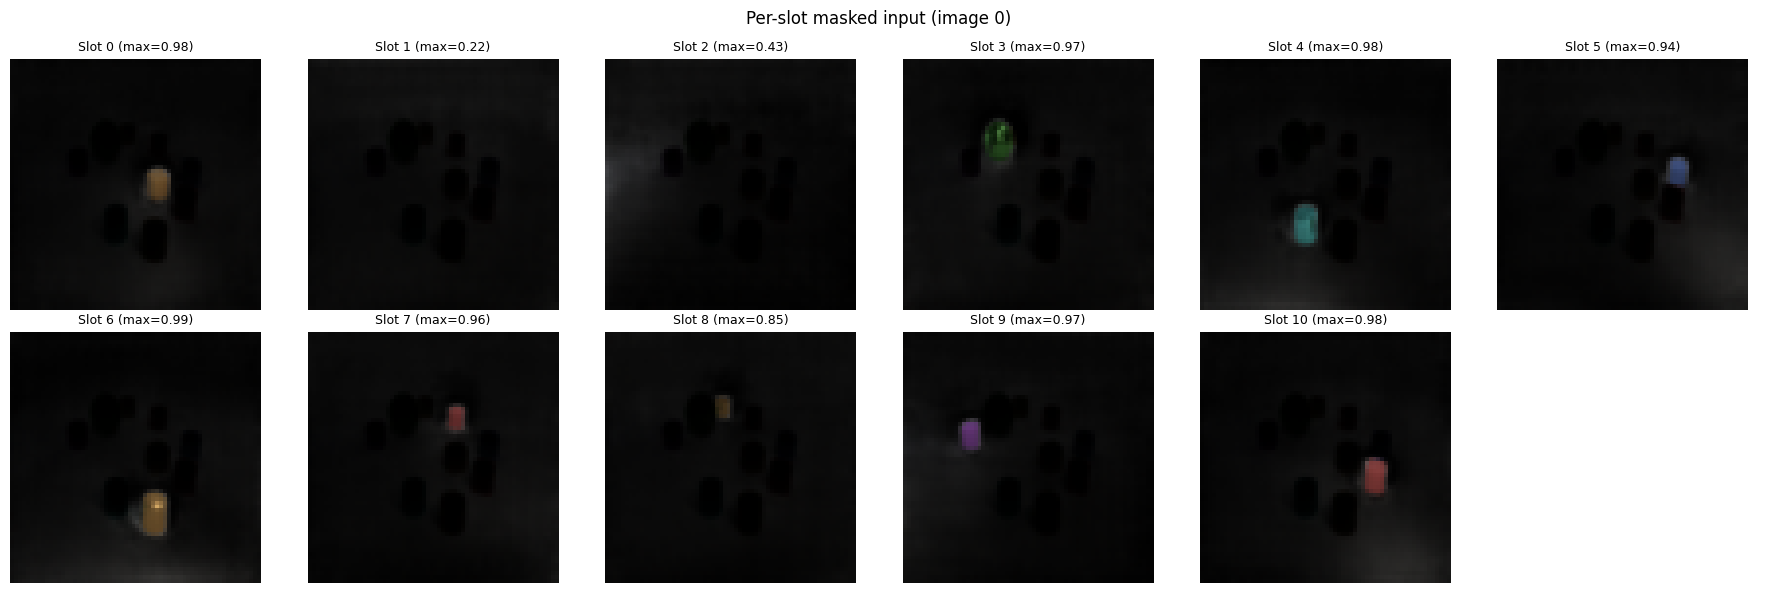

In [7]:
IMG_IDX = 0

n_cols = min(6, N_slots)
n_rows = (N_slots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
axes = np.array(axes).reshape(n_rows, n_cols)

for s in range(N_slots):
    r, c = divmod(s, n_cols)
    mask_s = masks_np[IMG_IDX, s]  # [H, W]
    masked_img = to_img(imgs_np[IMG_IDX]) * mask_s[..., None]
    axes[r, c].imshow(masked_img)
    axes[r, c].set_title(f"Slot {s} (max={mask_s.max():.2f})", fontsize=9)
    axes[r, c].axis("off")

for s in range(N_slots, n_rows * n_cols):
    r, c = divmod(s, n_cols)
    axes[r, c].axis("off")

fig.suptitle(f"Per-slot masked input (image {IMG_IDX})", fontsize=12)
plt.tight_layout()
plt.show()

## 6. Slot mask evolution across ODE time

We decode slot representations at intermediate ODE time steps to see how the masks sharpen.

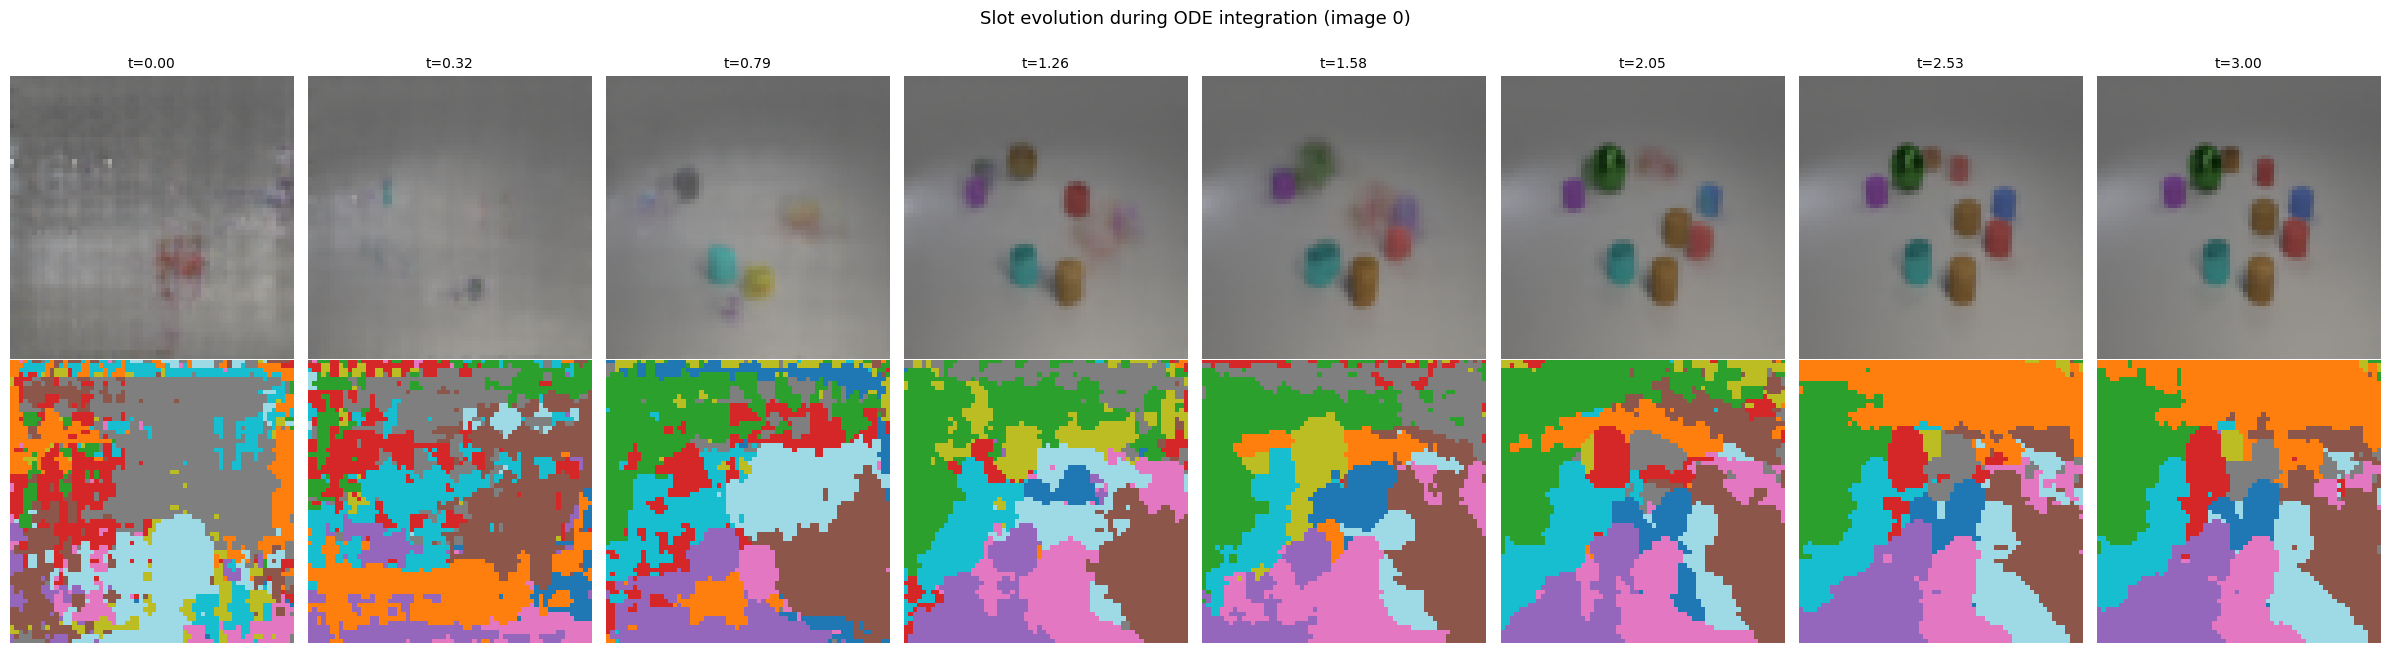

In [8]:
traj_np = np.array(traj)  # [T, B, N_slots, D_slot]
T_pts = traj_np.shape[0]

time_indices = np.linspace(0, T_pts - 1, 8, dtype=int)
T_show = float(model.slot_attention_ode.T)
time_values = np.linspace(0, T_show, T_pts)

@eqx.filter_jit
def decode_slots(model, slots):
    return model.dec(slots)

IMG_IDX = 0
n_time = len(time_indices)

fig, axes = plt.subplots(2, n_time, figsize=(3 * n_time, 6.5))

for col, ti in enumerate(time_indices):
    slots_t = jnp.array(traj_np[ti, IMG_IDX:IMG_IDX+1])  # [1, N_slots, D_slot]
    recon_t, masks_t = decode_slots(model, slots_t)
    recon_t_np = np.array(recon_t)
    masks_t_np = np.array(masks_t)

    axes[0, col].imshow(to_img(recon_t_np[0]))
    axes[0, col].set_title(f"t={time_values[ti]:.2f}", fontsize=10)
    axes[0, col].axis("off")

    seg = masks_t_np[0].argmax(axis=0)
    seg_rgb = np.zeros((*seg.shape, 3))
    for s in range(N_slots):
        seg_rgb[seg == s] = slot_colors[s]
    axes[1, col].imshow(seg_rgb)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Reconstruction", fontsize=10)
axes[1, 0].set_ylabel("Segmentation", fontsize=10)
fig.suptitle(f"Slot evolution during ODE integration (image {IMG_IDX})", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. Per-slot mask sharpening over time

Track how individual slot masks evolve. For each active slot, show the mask at several time points.

Active slots (max mask > 0.15): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


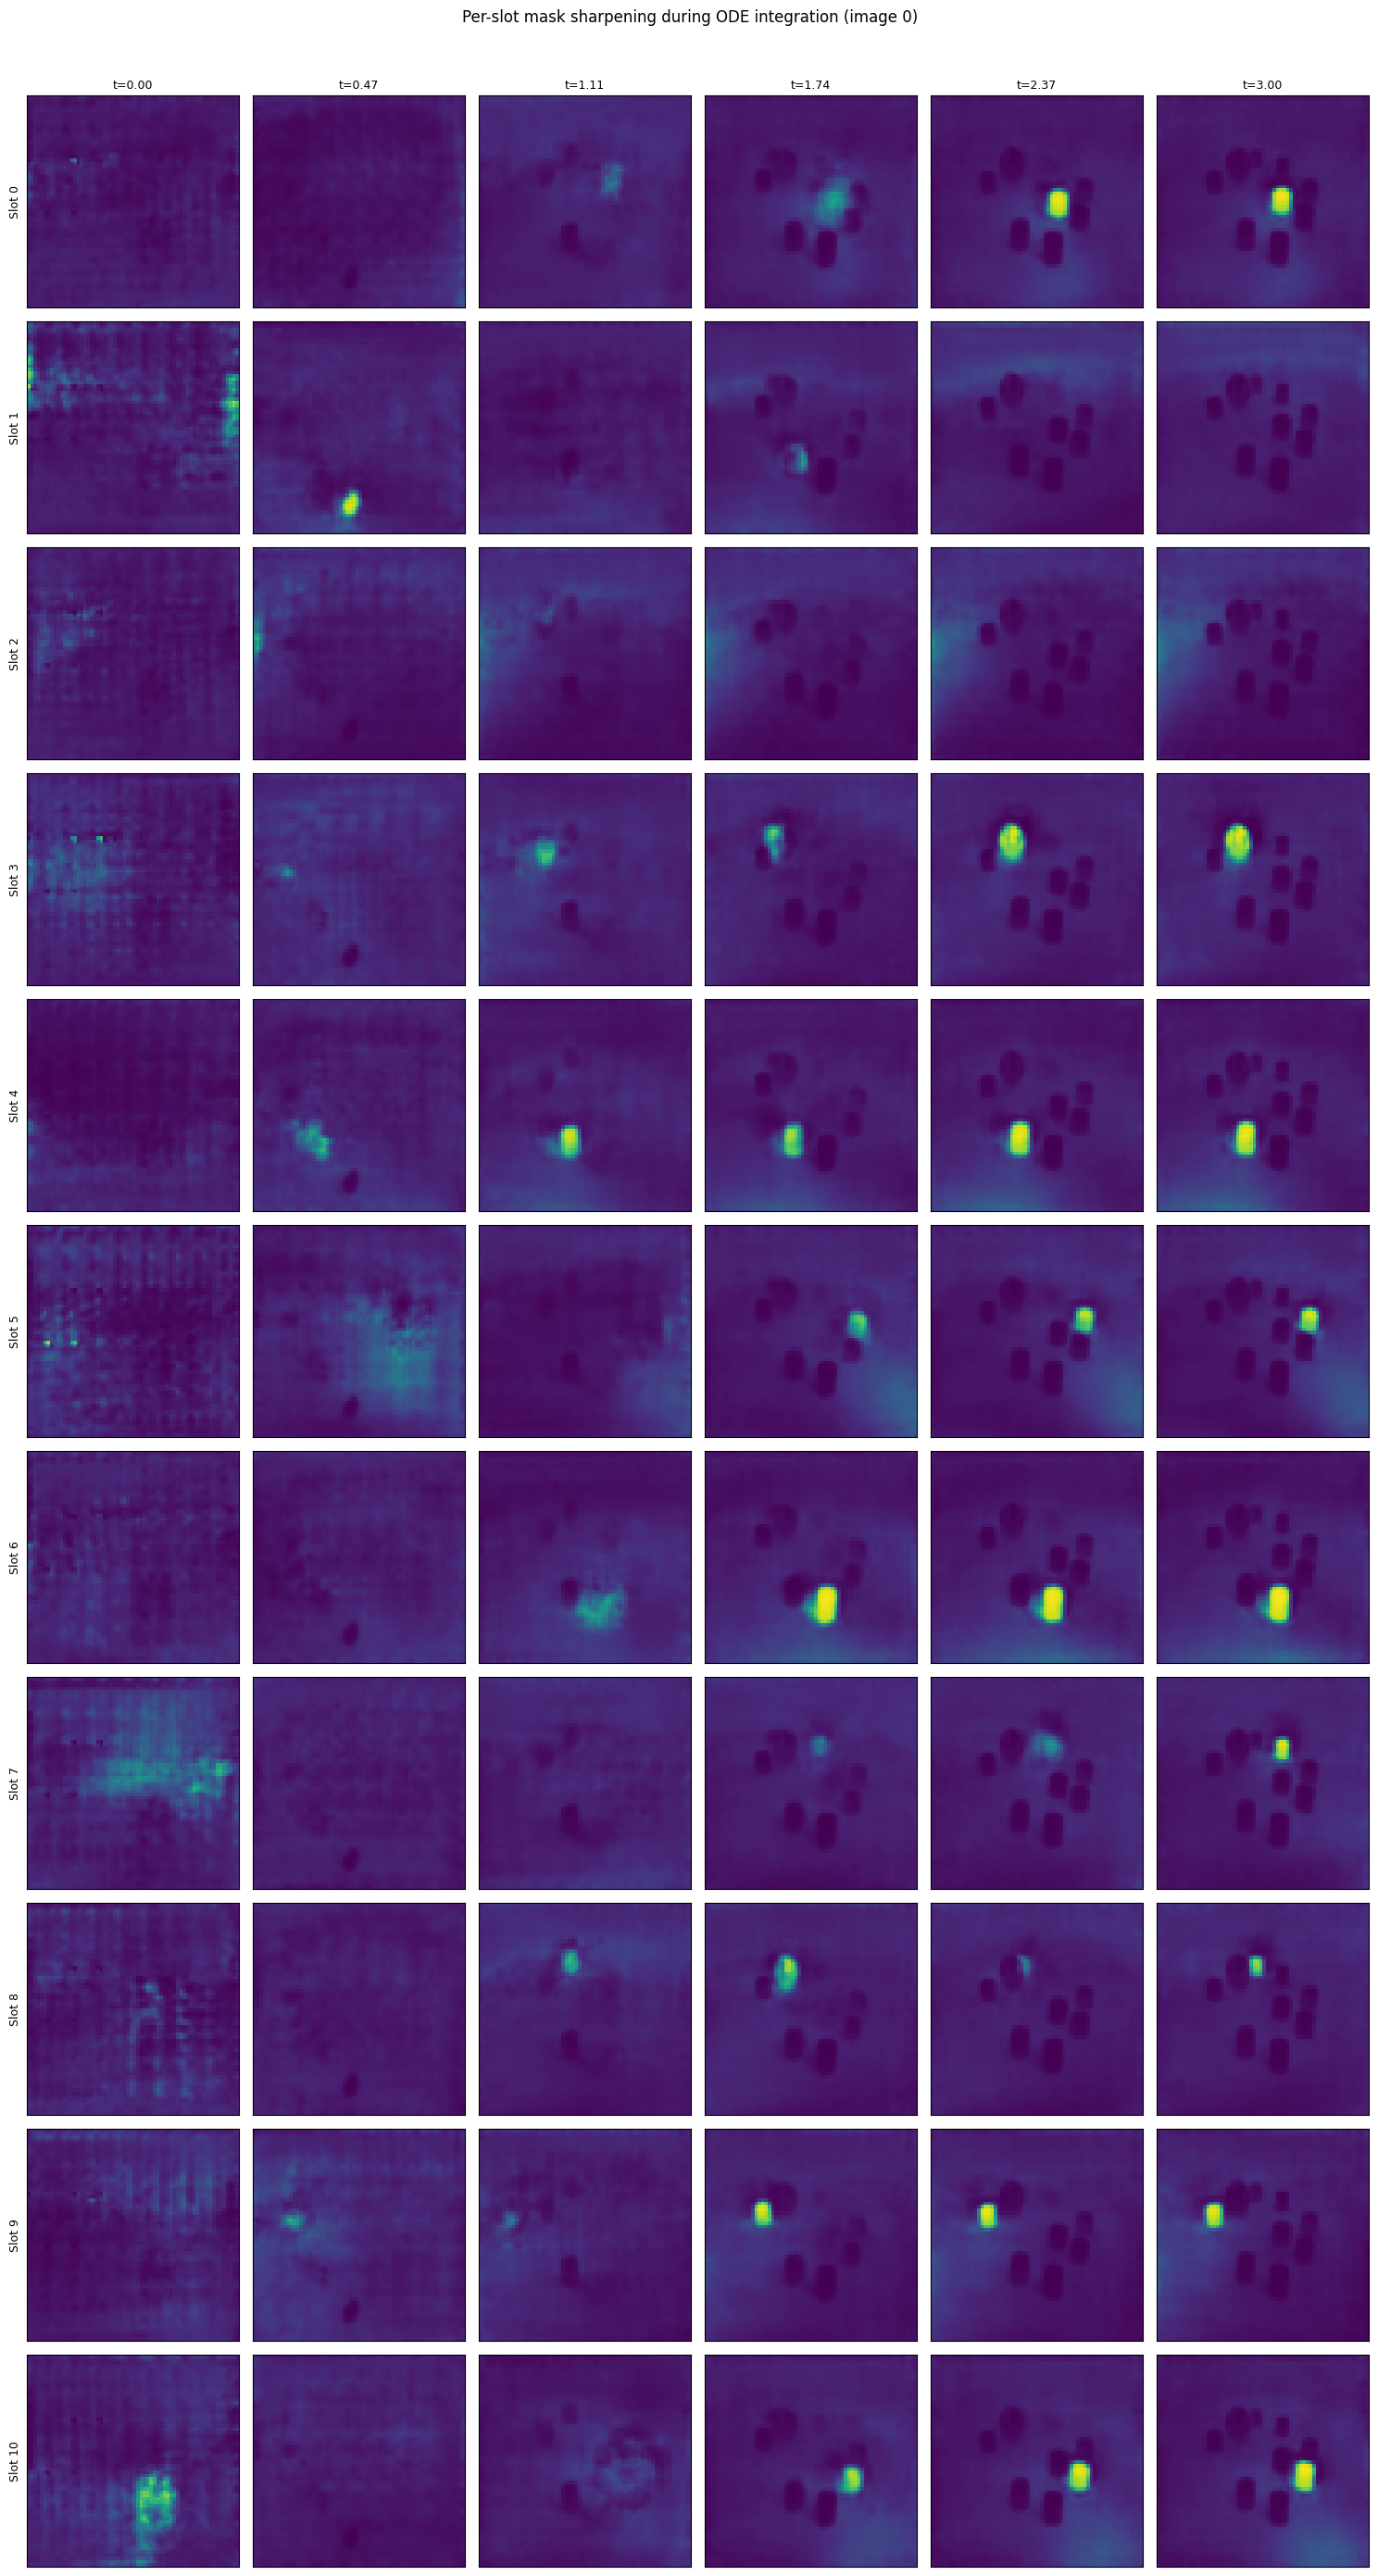

In [9]:
IMG_IDX = 0

final_masks = masks_np[IMG_IDX]  # [N_slots, H, W]
slot_activity = final_masks.max(axis=(1, 2))
active_slots = np.where(slot_activity > 0.15)[0]
print(f"Active slots (max mask > 0.15): {active_slots.tolist()}")

time_show = np.linspace(0, T_pts - 1, 6, dtype=int)

fig, axes = plt.subplots(len(active_slots), len(time_show),
                         figsize=(2.5 * len(time_show), 2.5 * len(active_slots)))
if len(active_slots) == 1:
    axes = axes[None, :]

for row, s in enumerate(active_slots):
    for col, ti in enumerate(time_show):
        slots_t = jnp.array(traj_np[ti, IMG_IDX:IMG_IDX+1])  # [1, N_slots, D]
        _, masks_t = decode_slots(model, slots_t)
        mask_s = np.array(masks_t[0, s])  # [H, W]

        axes[row, col].imshow(mask_s, cmap="viridis", vmin=0, vmax=1)
        if row == 0:
            axes[row, col].set_title(f"t={time_values[ti]:.2f}", fontsize=9)
        if col == 0:
            axes[row, col].set_ylabel(f"Slot {s}", fontsize=9)
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

fig.suptitle(f"Per-slot mask sharpening during ODE integration (image {IMG_IDX})", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 8. PCA of slot trajectories in latent space

Project the slot trajectories onto the first 2 principal components to visualize
how each slot's representation moves through latent space during integration.

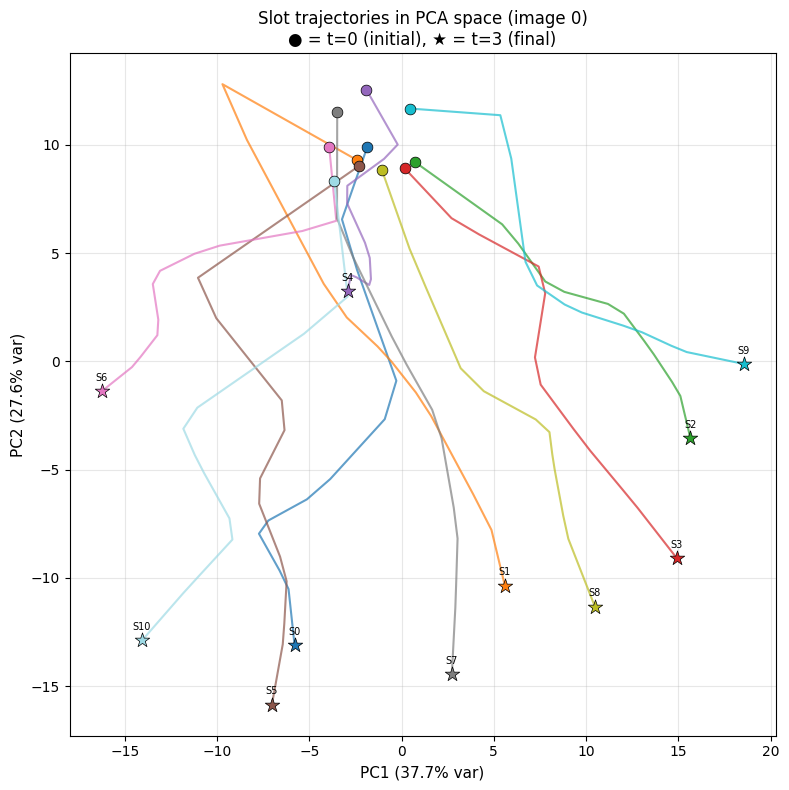

In [10]:
IMG_IDX = 0
traj_img = traj_np[:, IMG_IDX, :, :]  # [T, N_slots, D]
T_pts, N_s, D = traj_img.shape

all_pts = traj_img.reshape(-1, D)  # [T*N_slots, D]
pca = PCA(n_components=2)
pts_2d = pca.fit_transform(all_pts).reshape(T_pts, N_s, 2)  # [T, N_slots, 2]

fig, ax = plt.subplots(figsize=(8, 8))

for s in range(N_s):
    color = slot_colors[s]
    traj_s = pts_2d[:, s, :]  # [T, 2]
    ax.plot(traj_s[:, 0], traj_s[:, 1], color=color, alpha=0.7, linewidth=1.5)
    ax.scatter(traj_s[0, 0], traj_s[0, 1], color=color, marker="o", s=60,
              edgecolors="black", linewidths=0.5, zorder=5)
    ax.scatter(traj_s[-1, 0], traj_s[-1, 1], color=color, marker="*", s=120,
              edgecolors="black", linewidths=0.5, zorder=5)
    ax.annotate(f"S{s}", traj_s[-1], fontsize=7, ha="center", va="bottom",
               xytext=(0, 6), textcoords="offset points")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)", fontsize=11)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)", fontsize=11)
ax.set_title(f"Slot trajectories in PCA space (image {IMG_IDX})\n"
             f"● = t=0 (initial), ★ = t={T_show:.0f} (final)", fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Slot velocity magnitude over time

Shows how fast slots are moving at each point during integration. Convergence = velocity → 0.

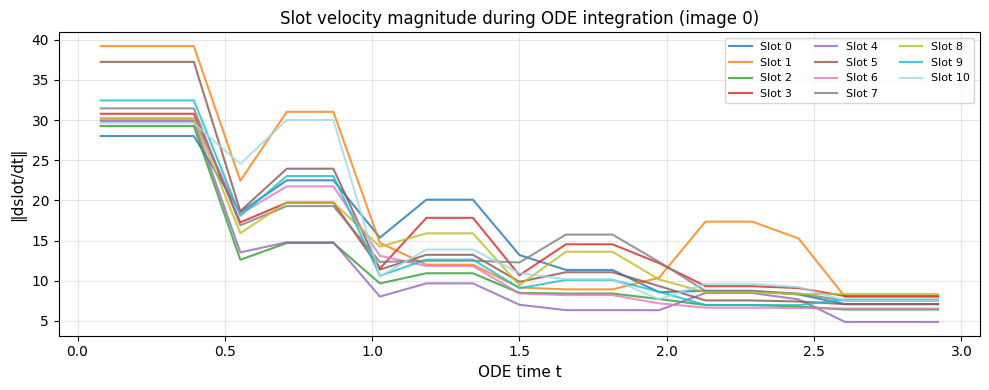

In [11]:
IMG_IDX = 0
traj_img = traj_np[:, IMG_IDX, :, :]  # [T, N_slots, D]

velocities = np.diff(traj_img, axis=0)  # [T-1, N_slots, D]
dt = time_values[1] - time_values[0]
speed = np.linalg.norm(velocities, axis=-1) / dt  # [T-1, N_slots]

fig, ax = plt.subplots(figsize=(10, 4))
t_mid = (time_values[:-1] + time_values[1:]) / 2

for s in range(N_s):
    label = f"Slot {s}" if slot_activity[s] > 0.15 else None
    alpha = 0.8 if slot_activity[s] > 0.15 else 0.2
    ax.plot(t_mid, speed[:, s], color=slot_colors[s], alpha=alpha, linewidth=1.5, label=label)

ax.set_xlabel("ODE time t", fontsize=11)
ax.set_ylabel("‖dslot/dt‖", fontsize=11)
ax.set_title(f"Slot velocity magnitude during ODE integration (image {IMG_IDX})", fontsize=12)
ax.legend(fontsize=8, ncol=3, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Autonomous dynamics analysis

Since the model is autonomous (fixed weights, no hypernetwork), all change in Q comes from
slot evolution: `Q(t) = LayerNorm(slots(t)) @ W_q`. We analyze:
1. **Velocity decay** — does ‖f(slots)‖ → 0? (convergence to a fixed point)
2. **Attention sharpening** — does attention entropy decrease over time?
3. **Loss as Lyapunov function** — does reconstruction MSE decrease along the ODE trajectory?

The paper finds that trained DiffEqFormers exhibit *increasing* eigenvalue magnitudes toward later layers,
preventing the clustering behavior predicted by weight-sharing theories (Geshkovski et al. 2023).

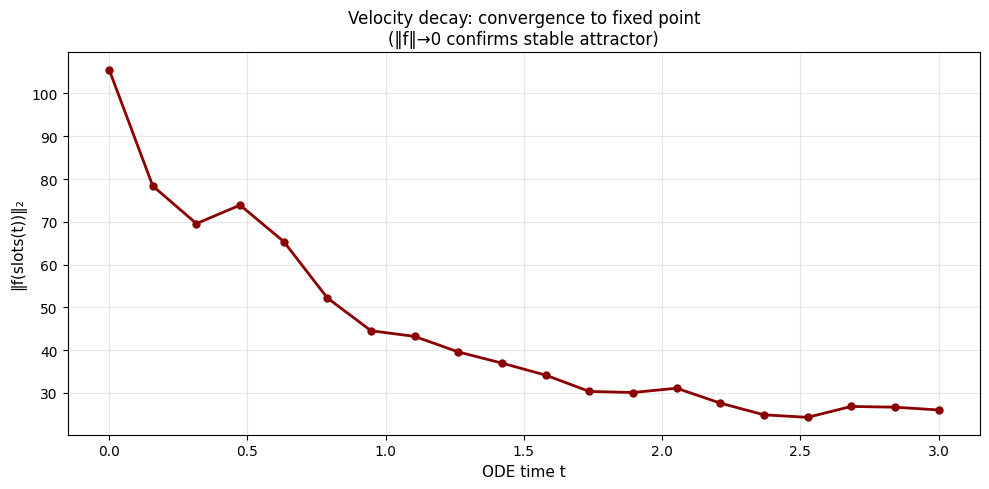

In [12]:
IMG_IDX = 0
sa = model.slot_attention_ode
ode_func = sa.slot_ode_func

enc_feat_vel = model.enc(images_jax)
feat_norm_vel = jax.vmap(jax.vmap(sa.norm_input))(enc_feat_vel)
feat_vel = jax.vmap(jax.vmap(sa.fc_input))(feat_norm_vel)
k_vel = jax.vmap(jax.vmap(sa.to_k))(feat_vel)
v_vel = jax.vmap(jax.vmap(sa.to_v))(feat_vel)

traj_vel = traj_np[:, IMG_IDX, :, :]  # [T, N_slots, D]
T_pts_vel = traj_vel.shape[0]
time_values_vel = np.linspace(0, float(sa.T), T_pts_vel)

velocity_norms = np.zeros(T_pts_vel)
for ti in range(T_pts_vel):
    slots_ti = jnp.array(traj_vel[ti:ti+1])  # [1, N_slots, D]
    t_val = time_values_vel[ti]
    vel = ode_func(t_val, slots_ti, (k_vel[IMG_IDX:IMG_IDX+1], v_vel[IMG_IDX:IMG_IDX+1]))
    velocity_norms[ti] = float(jnp.linalg.norm(vel))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(time_values_vel, velocity_norms, "o-", linewidth=2, markersize=5, color="darkred")
ax.set_xlabel("ODE time t", fontsize=11)
ax.set_ylabel("‖f(slots(t))‖₂", fontsize=11)
ax.set_title("Velocity decay: convergence to fixed point\n"
             "(‖f‖→0 confirms stable attractor)", fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

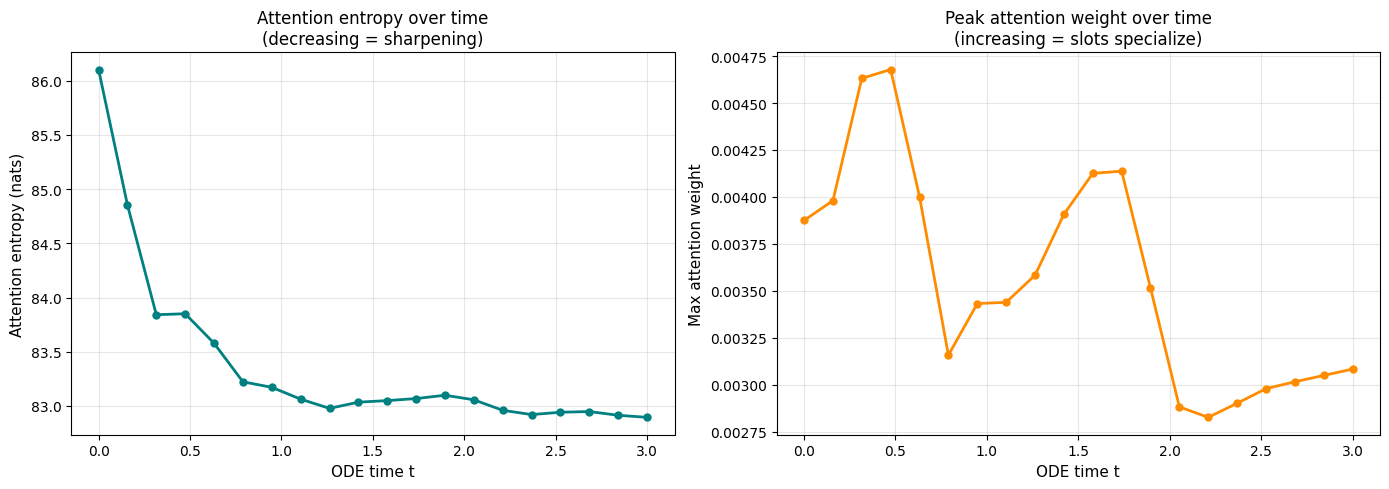

In [13]:
IMG_IDX = 0
sa = model.slot_attention_ode
ode_func = sa.slot_ode_func

traj_attn = traj_np[:, IMG_IDX, :, :]  # [T, N_slots, D]
T_pts_attn = traj_attn.shape[0]
time_values_attn = np.linspace(0, float(sa.T), T_pts_attn)

@jax.jit
def compute_attention(slots_t, k_in):
    """Compute attention weights for a single trajectory point."""
    if ode_func.autonomous:
        Wq = ode_func.W_q
    else:
        Wq = ode_func.tdw_q(0.0)
    slots_norm = jax.vmap(jax.vmap(ode_func.norm_attn))(slots_t)
    q = jnp.einsum('bnd,od->bno', slots_norm, Wq)
    att_logits = jnp.einsum('bnd,bmd->bnm', q, k_in) * ode_func.scale
    att = jax.nn.softmax(att_logits, axis=1)
    att = att / (att.sum(axis=-1, keepdims=True) + 1e-8)
    return att

entropies = np.zeros(T_pts_attn)
max_attns = np.zeros(T_pts_attn)
for ti in range(T_pts_attn):
    slots_ti = jnp.array(traj_attn[ti:ti+1])
    att_ti = np.array(compute_attention(slots_ti, k_vel[IMG_IDX:IMG_IDX+1]))
    att_flat = att_ti.flatten()
    att_flat = att_flat[att_flat > 1e-10]
    entropies[ti] = float(-np.sum(att_flat * np.log(att_flat)))
    max_attns[ti] = float(att_ti.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(time_values_attn, entropies, "o-", linewidth=2, markersize=5, color="teal")
ax.set_xlabel("ODE time t", fontsize=11)
ax.set_ylabel("Attention entropy (nats)", fontsize=11)
ax.set_title("Attention entropy over time\n(decreasing = sharpening)", fontsize=12)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(time_values_attn, max_attns, "o-", linewidth=2, markersize=5, color="darkorange")
ax.set_xlabel("ODE time t", fontsize=11)
ax.set_ylabel("Max attention weight", fontsize=11)
ax.set_title("Peak attention weight over time\n(increasing = slots specialize)", fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

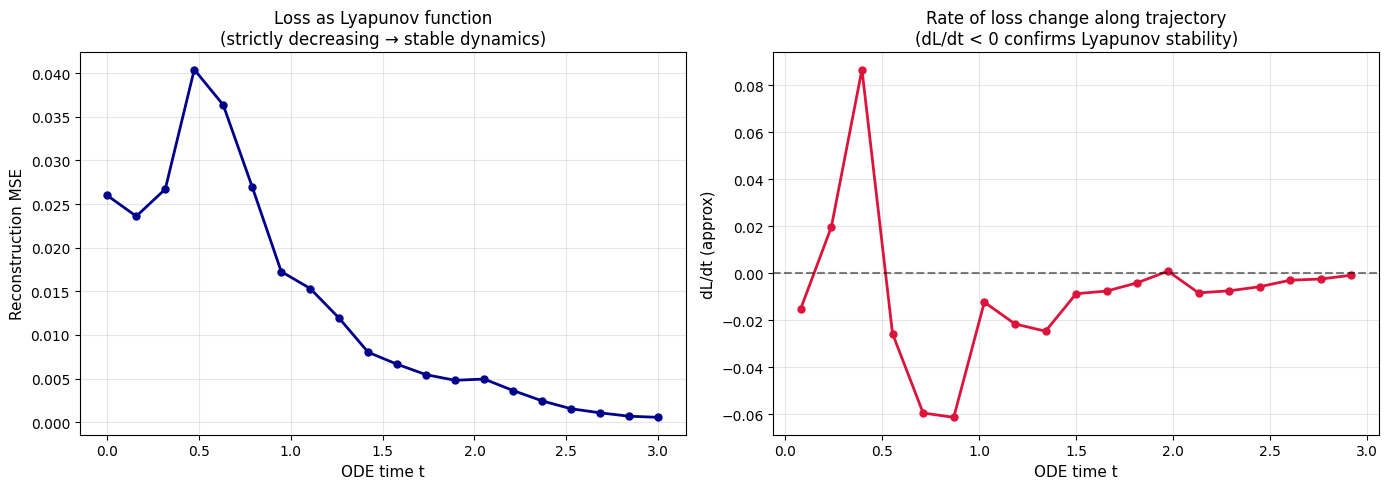

In [14]:
IMG_IDX = 0
traj_lyap = traj_np[:, IMG_IDX, :, :]  # [T, N_slots, D]
T_pts_lyap = traj_lyap.shape[0]
time_values_lyap = np.linspace(0, float(model.slot_attention_ode.T), T_pts_lyap)

@eqx.filter_jit
def decode_from_slots(model, slots_1img):
    """Decode reconstruction and masks from a single image's slots."""
    slots_batch = jnp.expand_dims(slots_1img, axis=0)  # [1, N_slots, D]
    recon, masks = model.dec(slots_batch)
    return recon[0], masks[0]  # [3,H,W], [N_slots,H,W]

single_img = images_jax[IMG_IDX]  # [3, H, W]
mse_trajectory = np.zeros(T_pts_lyap)
for ti in range(T_pts_lyap):
    slots_ti = jnp.array(traj_lyap[ti])  # [N_slots, D]
    recon_ti, _ = decode_from_slots(model, slots_ti)
    mse_trajectory[ti] = float(jnp.mean((recon_ti - single_img) ** 2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(time_values_lyap, mse_trajectory, "o-", linewidth=2, markersize=5, color="darkblue")
ax.set_xlabel("ODE time t", fontsize=11)
ax.set_ylabel("Reconstruction MSE", fontsize=11)
ax.set_title("Loss as Lyapunov function\n(strictly decreasing → stable dynamics)", fontsize=12)
ax.grid(True, alpha=0.3)

ax = axes[1]
dL_dt = np.diff(mse_trajectory) / np.diff(time_values_lyap)
t_mid = 0.5 * (time_values_lyap[:-1] + time_values_lyap[1:])
ax.plot(t_mid, dL_dt, "o-", linewidth=2, markersize=5, color="crimson")
ax.axhline(0, color="black", linestyle="--", alpha=0.5)
ax.set_xlabel("ODE time t", fontsize=11)
ax.set_ylabel("dL/dt (approx)", fontsize=11)
ax.set_title("Rate of loss change along trajectory\n(dL/dt < 0 confirms Lyapunov stability)", fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 10d. Jacobian spectral radius at the fixed point

For an autonomous ODE `d(slots)/dt = f(slots)`, stability of the terminal state (approximate fixed point)
is determined by the Jacobian `∂f/∂slots` evaluated there. If all eigenvalues have negative real part,
the fixed point is a **stable attractor** — confirming that the model converges to a well-defined object decomposition.

E0318 16:09:52.807442   31164 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0318 16:09:52.985213   31173 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


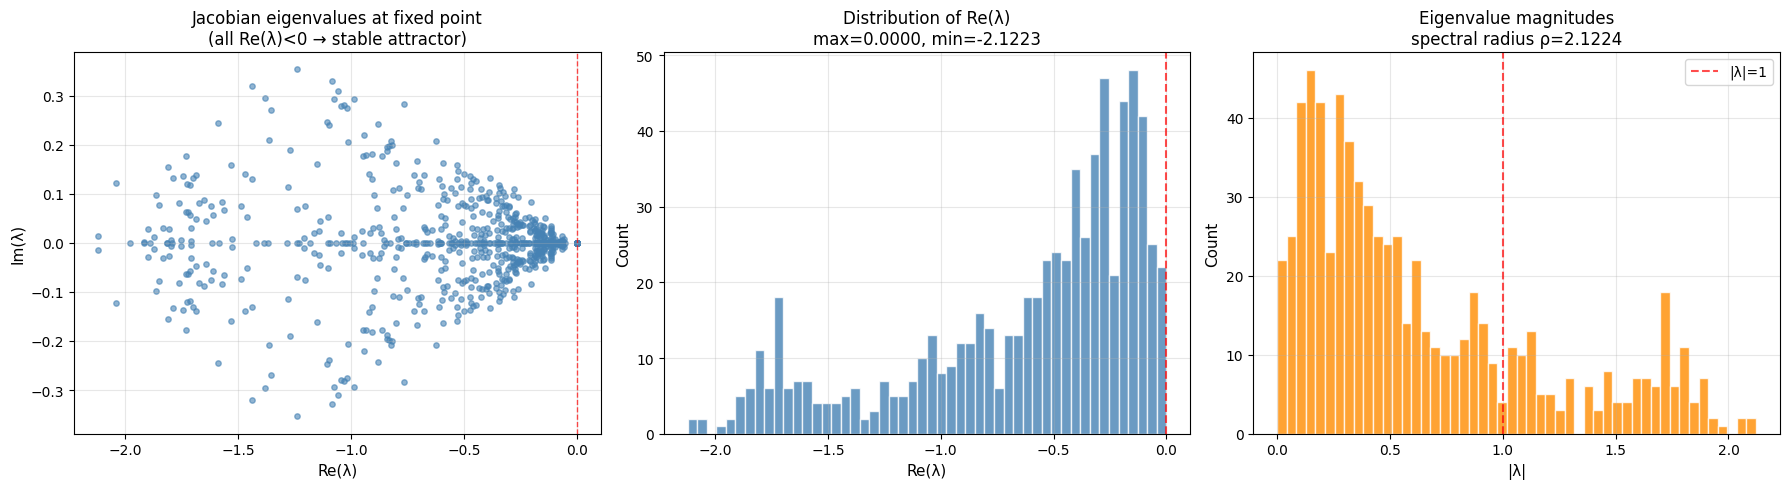

Jacobian at fixed point: 98.0% of eigenvalues have Re(λ) < 0
Spectral radius: 2.1224
Max Re(λ): 0.000040


In [15]:
IMG_IDX = 0
sa = model.slot_attention_ode
ode_func = sa.slot_ode_func

slots_final_fp = jnp.array(traj_np[-1, IMG_IDX:IMG_IDX+1])  # [1, N_slots, D]
t_final = float(sa.T)

def f_flat(slots_flat):
    """Wrap ODE func for Jacobian: flat vector -> flat vector."""
    slots_3d = slots_flat.reshape(1, slots_final_fp.shape[1], slots_final_fp.shape[2])
    vel = ode_func(t_final, slots_3d, (k_vel[IMG_IDX:IMG_IDX+1], v_vel[IMG_IDX:IMG_IDX+1]))
    return vel.flatten()

jac_fn = jax.jit(jax.jacfwd(f_flat))
slots_flat = slots_final_fp.flatten()
J = np.array(jac_fn(slots_flat))

eigs_J = np.linalg.eigvals(J)
reals = eigs_J.real

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.scatter(eigs_J.real, eigs_J.imag, s=15, alpha=0.6, color="steelblue")
ax.axvline(0, color="red", linestyle="--", linewidth=1, alpha=0.7)
ax.set_xlabel("Re(λ)", fontsize=11)
ax.set_ylabel("Im(λ)", fontsize=11)
ax.set_title("Jacobian eigenvalues at fixed point\n(all Re(λ)<0 → stable attractor)", fontsize=12)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(reals, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(0, color="red", linestyle="--", linewidth=1.5, alpha=0.7)
ax.set_xlabel("Re(λ)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title(f"Distribution of Re(λ)\nmax={reals.max():.4f}, min={reals.min():.4f}", fontsize=12)
ax.grid(True, alpha=0.3)

ax = axes[2]
mags = np.abs(eigs_J)
ax.hist(mags, bins=50, color="darkorange", edgecolor="white", alpha=0.8)
ax.axvline(1.0, color="red", linestyle="--", linewidth=1.5, alpha=0.7, label="|λ|=1")
ax.set_xlabel("|λ|", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title(f"Eigenvalue magnitudes\nspectral radius ρ={mags.max():.4f}", fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

pct_stable = (reals < 0).sum() / len(reals) * 100
print(f"Jacobian at fixed point: {pct_stable:.1f}% of eigenvalues have Re(λ) < 0")
print(f"Spectral radius: {mags.max():.4f}")
print(f"Max Re(λ): {reals.max():.6f}")

## 12. Stability analysis & attractors

### 12a. Jacobian eigenvalues along the trajectory

For a non-autonomous ODE ẋ = f(t, x, args), local stability is determined by the Jacobian
J(t) = ∂f/∂x evaluated along the trajectory. If Re(λ_i(J)) < 0 at a point, the flow is locally
contracting there (attracting). If Re(λ_i(J)) > 0, it's locally expanding (repelling).

We compute J at several time points by differentiating the ODE vector field w.r.t. the slot state.

In [16]:
IMG_IDX = 0

enc_feat = model.enc(images_jax)
feat_norm = jax.vmap(jax.vmap(model.slot_attention_ode.norm_input))(enc_feat)
feat = jax.vmap(jax.vmap(model.slot_attention_ode.fc_input))(feat_norm)
k_feat = jax.vmap(jax.vmap(model.slot_attention_ode.to_k))(feat)
v_feat = jax.vmap(jax.vmap(model.slot_attention_ode.to_v))(feat)

k_single = k_feat[IMG_IDX:IMG_IDX+1]  # [1, N_feat, D]
v_single = v_feat[IMG_IDX:IMG_IDX+1]  # [1, N_feat, D]

ode_func = model.slot_attention_ode.slot_ode_func

def velocity_flat(slots_flat, t):
    """ODE velocity for a single image, flattened slots."""
    slots = slots_flat.reshape(1, N_slots, -1)
    vel = ode_func(t, slots, (k_single, v_single))
    return vel.reshape(-1)

@jax.jit
def jacobian_eigs_at(slots_flat, t):
    J = jax.jacobian(velocity_flat)(slots_flat, t)  # [N_slots*D, N_slots*D]
    return J

n_jac_pts = 15
jac_time_indices = np.linspace(0, T_pts - 1, n_jac_pts, dtype=int)

jac_eigs_list = []
jac_traces = []
for ti in jac_time_indices:
    slots_t = traj_np[ti, IMG_IDX]  # [N_slots, D]
    slots_flat = jnp.array(slots_t.reshape(-1))
    t_val = time_values[ti]

    J = np.array(jacobian_eigs_at(slots_flat, t_val))
    eig_vals = np.linalg.eigvals(J)
    jac_eigs_list.append(eig_vals)
    jac_traces.append(np.trace(J))
    print(f"  t={t_val:.2f}: max Re(λ)={eig_vals.real.max():.3f}, "
          f"min Re(λ)={eig_vals.real.min():.3f}, tr(J)={np.trace(J).real:.3f}")

print(f"\nJacobian size: {J.shape} ({N_slots}×{slots.shape[-1]} = {N_slots * slots.shape[-1]} dims)")

E0318 16:09:56.534169   31159 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  t=0.00: max Re(λ)=5.278, min Re(λ)=-5.117, tr(J)=-719.220


  t=0.16: max Re(λ)=13.560, min Re(λ)=-14.038, tr(J)=-900.292


  t=0.32: max Re(λ)=33.108, min Re(λ)=-6.612, tr(J)=-795.738


  t=0.63: max Re(λ)=1.924, min Re(λ)=-3.542, tr(J)=-643.416


...

  t=2.05: max Re(λ)=1.260, min Re(λ)=-2.762, tr(J)=-554.910


  t=2.21: max Re(λ)=0.976, min Re(λ)=-2.642, tr(J)=-536.905


  t=2.53: max Re(λ)=11.336, min Re(λ)=-2.374, tr(J)=-481.073


  t=2.68: max Re(λ)=2.790, min Re(λ)=-2.308, tr(J)=-467.724


  t=3.00: max Re(λ)=0.000, min Re(λ)=-2.122, tr(J)=-436.330

Jacobian size: (704, 704) (11×64 = 704 dims)


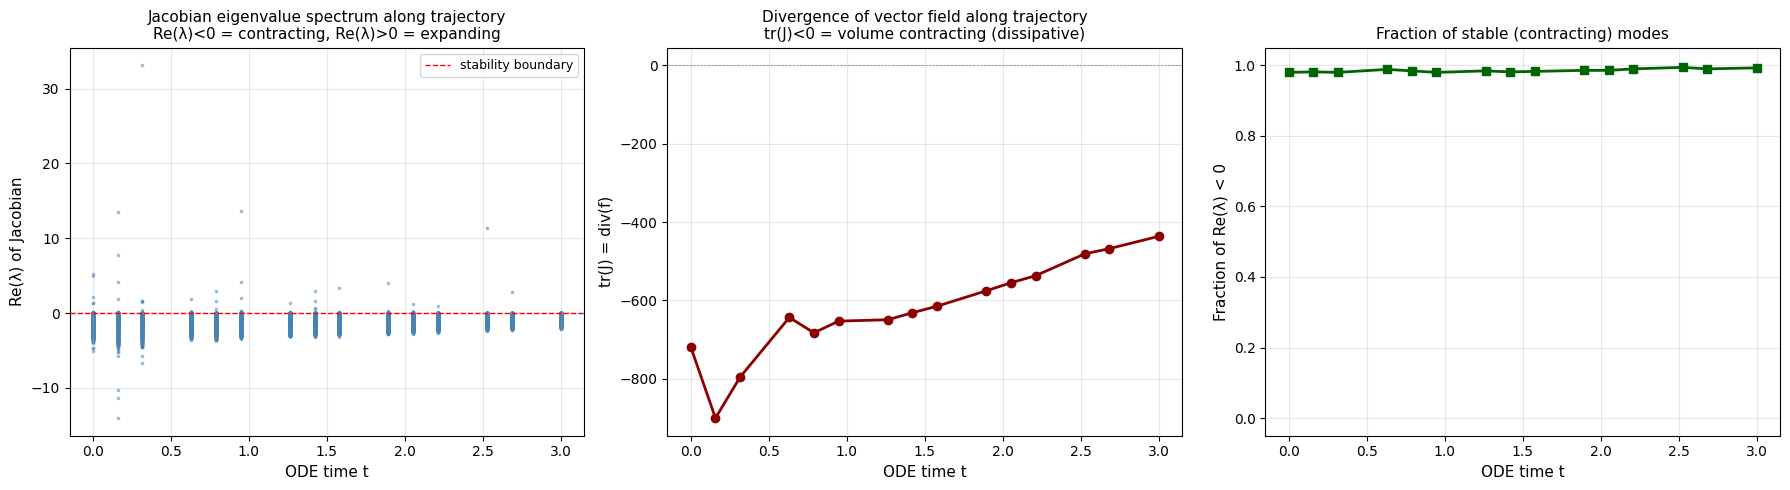

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Re(λ) of Jacobian over time ---
ax = axes[0]
for i, ti in enumerate(jac_time_indices):
    t_val = time_values[ti]
    eigs = jac_eigs_list[i]
    ax.scatter(np.full_like(eigs.real, t_val), eigs.real, s=3, alpha=0.4, color="steelblue")
ax.axhline(0, color="red", linewidth=1, linestyle="--", label="stability boundary")
ax.set_xlabel("ODE time t", fontsize=11)
ax.set_ylabel("Re(λ) of Jacobian", fontsize=11)
ax.set_title("Jacobian eigenvalue spectrum along trajectory\nRe(λ)<0 = contracting, Re(λ)>0 = expanding", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- trace(J) over time = divergence of vector field ---
ax = axes[1]
t_jac = [time_values[ti] for ti in jac_time_indices]
ax.plot(t_jac, [tr.real for tr in jac_traces], "o-", linewidth=2, color="darkred", markersize=6)
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax.set_xlabel("ODE time t", fontsize=11)
ax.set_ylabel("tr(J) = div(f)", fontsize=11)
ax.set_title("Divergence of vector field along trajectory\ntr(J)<0 = volume contracting (dissipative)", fontsize=11)
ax.grid(True, alpha=0.3)

# --- fraction of eigenvalues with Re(λ) < 0 ---
ax = axes[2]
frac_stable = [np.mean(e.real < 0) for e in jac_eigs_list]
ax.plot(t_jac, frac_stable, "s-", linewidth=2, color="darkgreen", markersize=6)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("ODE time t", fontsize=11)
ax.set_ylabel("Fraction of Re(λ) < 0", fontsize=11)
ax.set_title("Fraction of stable (contracting) modes", fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 12b. Basin of attraction — convergence from different initializations

Run the model from many different random seeds (different slot initializations) on the same image.
If final slots converge to similar representations (up to permutation), the system has a strong attractor.

In [18]:
N_SEEDS = 20
IMG_IDX = 0
single_img = images_jax[IMG_IDX:IMG_IDX+1]  # [1, 3, H, W]

@eqx.filter_jit
def forward_single(model, img, key):
    recon, masks, slots = model(img, key=key)
    return slots, masks

all_final_slots = []
all_final_masks = []
for seed in range(N_SEEDS):
    s, m = forward_single(model, single_img, jax.random.key(seed))
    all_final_slots.append(np.array(s[0]))   # [N_slots, D]
    all_final_masks.append(np.array(m[0]))    # [N_slots, H, W]

all_final_slots = np.stack(all_final_slots)  # [N_SEEDS, N_slots, D]
all_final_masks = np.stack(all_final_masks)  # [N_SEEDS, N_slots, H, W]
print(f"Collected {N_SEEDS} runs, slots shape: {all_final_slots.shape}")

E0318 16:10:04.104169   31182 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Collected 20 runs, slots shape: (20, 11, 64)


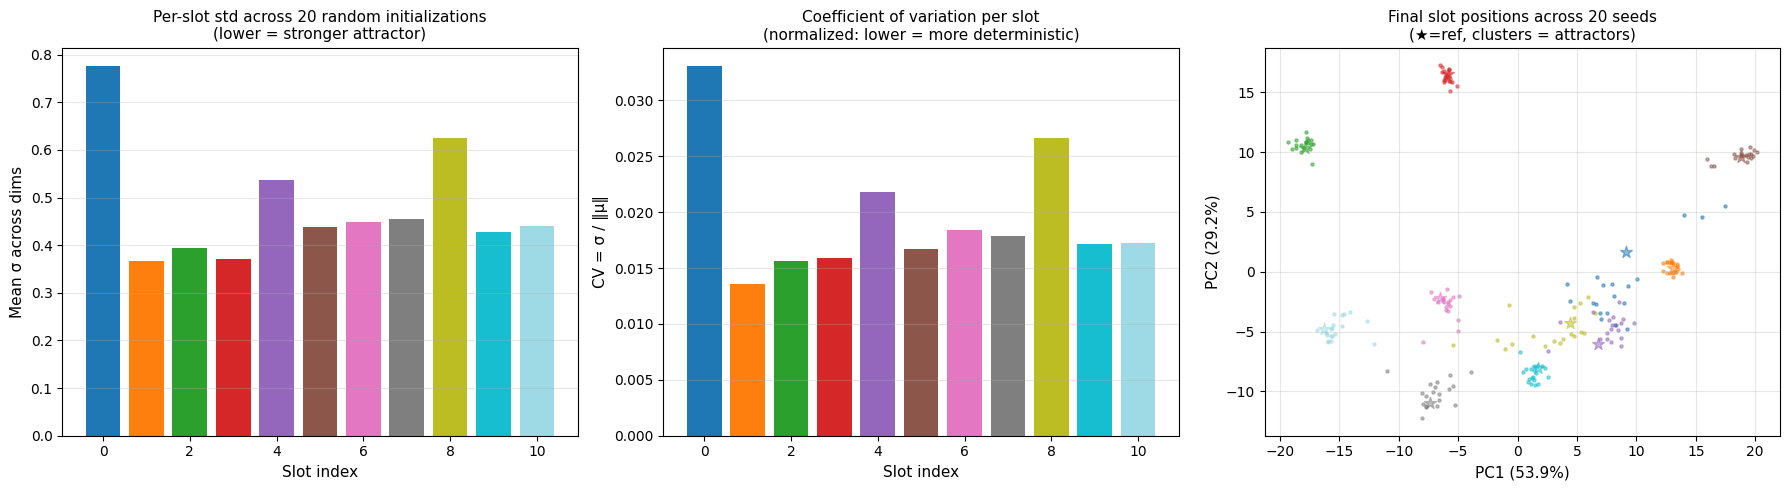

In [19]:
from scipy.optimize import linear_sum_assignment

def hungarian_match_slots(ref_slots, target_slots):
    """Match target slots to ref slots via Hungarian algorithm on cosine distance."""
    ref_norm = ref_slots / (np.linalg.norm(ref_slots, axis=-1, keepdims=True) + 1e-8)
    tgt_norm = target_slots / (np.linalg.norm(target_slots, axis=-1, keepdims=True) + 1e-8)
    cost = 1 - ref_norm @ tgt_norm.T  # [N, N] cosine distance
    row_ind, col_ind = linear_sum_assignment(cost)
    return col_ind  # permutation: target[col_ind[i]] matches ref[i]

ref_slots = all_final_slots[0]  # use seed 0 as reference
aligned_slots = [ref_slots]
for i in range(1, N_SEEDS):
    perm = hungarian_match_slots(ref_slots, all_final_slots[i])
    aligned_slots.append(all_final_slots[i][perm])
aligned_slots = np.stack(aligned_slots)  # [N_SEEDS, N_slots, D]

slot_std = aligned_slots.std(axis=0)  # [N_slots, D]
slot_mean_std = slot_std.mean(axis=-1)  # [N_slots]
slot_rep_norm = np.linalg.norm(aligned_slots.mean(axis=0), axis=-1)  # [N_slots]
coeff_of_variation = slot_mean_std / (slot_rep_norm + 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.bar(range(N_slots), slot_mean_std, color=[slot_colors[s] for s in range(N_slots)])
ax.set_xlabel("Slot index", fontsize=11)
ax.set_ylabel("Mean σ across dims", fontsize=11)
ax.set_title(f"Per-slot std across {N_SEEDS} random initializations\n(lower = stronger attractor)", fontsize=11)
ax.grid(True, alpha=0.3, axis="y")

ax = axes[1]
ax.bar(range(N_slots), coeff_of_variation, color=[slot_colors[s] for s in range(N_slots)])
ax.set_xlabel("Slot index", fontsize=11)
ax.set_ylabel("CV = σ / ‖μ‖", fontsize=11)
ax.set_title("Coefficient of variation per slot\n(normalized: lower = more deterministic)", fontsize=11)
ax.grid(True, alpha=0.3, axis="y")

# PCA of all final slots from all seeds together
ax = axes[2]
all_flat = aligned_slots.reshape(-1, aligned_slots.shape[-1])  # [N_SEEDS*N_slots, D]
pca_basin = PCA(n_components=2)
pts_2d = pca_basin.fit_transform(all_flat).reshape(N_SEEDS, N_slots, 2)
for seed in range(N_SEEDS):
    for s in range(N_slots):
        marker = "*" if seed == 0 else "."
        size = 80 if seed == 0 else 20
        ax.scatter(pts_2d[seed, s, 0], pts_2d[seed, s, 1],
                  color=slot_colors[s], marker=marker, s=size, alpha=0.5)
ax.set_xlabel(f"PC1 ({pca_basin.explained_variance_ratio_[0]:.1%})", fontsize=11)
ax.set_ylabel(f"PC2 ({pca_basin.explained_variance_ratio_[1]:.1%})", fontsize=11)
ax.set_title(f"Final slot positions across {N_SEEDS} seeds\n(★=ref, clusters = attractors)", fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 12c. Perturbation growth — Lyapunov-style analysis

Perturb the initial slots by small ε in random directions, run the ODE, and track
how ‖x_perturbed(t) − x_reference(t)‖ evolves. Exponential decay = stable attractor.
The growth rate λ ≈ (1/t) log(‖δx(t)‖ / ‖δx(0)‖) is the finite-time Lyapunov exponent.

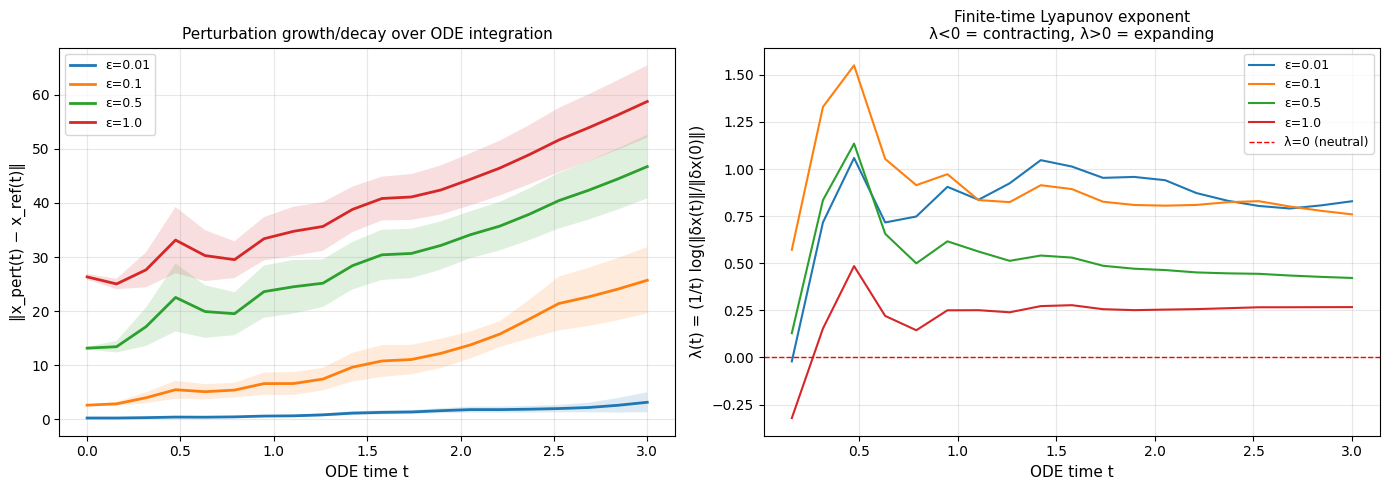

In [20]:
N_PERTURB = 10
EPSILONS = [0.01, 0.1, 0.5, 1.0]
IMG_IDX = 0

@eqx.filter_jit
def forward_traj_single(model, img, key):
    return model(img, key=key, return_traj=True)

ref_key = jax.random.key(42)
_, _, _, ref_traj = forward_traj_single(model, single_img, ref_key)
ref_traj_np = np.array(ref_traj[:, 0])  # [T, N_slots, D]
N_TRAJ = ref_traj_np.shape[0]
tvals_pert = np.linspace(0, T_show, N_TRAJ)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for eps in EPSILONS:
    all_separations = []
    for p in range(N_PERTURB):
        pert_key = jax.random.key(1000 + p)
        k1, k2 = jax.random.split(pert_key)

        # perturb the slot initialization by injecting noise into the key
        # we manually create perturbed initial slots and run the ODE
        enc_feat_s = model.enc(single_img)
        feat_norm_s = jax.vmap(jax.vmap(model.slot_attention_ode.norm_input))(enc_feat_s)
        feat_s = jax.vmap(jax.vmap(model.slot_attention_ode.fc_input))(feat_norm_s)
        k_s = jax.vmap(jax.vmap(model.slot_attention_ode.to_k))(feat_s)
        v_s = jax.vmap(jax.vmap(model.slot_attention_ode.to_v))(feat_s)

        slots_ref = model.slot_attention_ode.initialize_slots(1, ref_key)
        noise = eps * jax.random.normal(k2, slots_ref.shape)
        slots_pert = slots_ref + noise

        sa = model.slot_attention_ode
        term = diffrax.ODETerm(sa.slot_ode_func)
        solver = diffrax.Euler()
        saveat = diffrax.SaveAt(ts=jnp.linspace(0.0, sa.T, N_TRAJ))
        sol = diffrax.diffeqsolve(
            term, solver, t0=0.0, t1=sa.T, dt0=sa.dt0,
            y0=slots_pert, args=(k_s, v_s),
            saveat=saveat, stepsize_controller=diffrax.ConstantStepSize(),
            max_steps=256,
        )
        pert_traj = np.array(sol.ys[:, 0])  # [T, N_slots, D]

        sep = np.linalg.norm(pert_traj - ref_traj_np, axis=(-2, -1))  # [T]
        all_separations.append(sep)

    mean_sep = np.mean(all_separations, axis=0)
    std_sep = np.std(all_separations, axis=0)

    axes[0].plot(tvals_pert, mean_sep, linewidth=2, label=f"ε={eps}")
    axes[0].fill_between(tvals_pert, mean_sep - std_sep, mean_sep + std_sep, alpha=0.15)

    # finite-time Lyapunov exponent
    init_sep = mean_sep[0]
    with np.errstate(divide="ignore", invalid="ignore"):
        lyap = np.log(mean_sep / (init_sep + 1e-12)) / (tvals_pert + 1e-12)
    lyap[0] = 0
    axes[1].plot(tvals_pert[1:], lyap[1:], linewidth=1.5, label=f"ε={eps}")

ax = axes[0]
ax.set_xlabel("ODE time t", fontsize=11)
ax.set_ylabel("‖x_pert(t) − x_ref(t)‖", fontsize=11)
ax.set_title("Perturbation growth/decay over ODE integration", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.axhline(0, color="red", linewidth=1, linestyle="--", label="λ=0 (neutral)")
ax.set_xlabel("ODE time t", fontsize=11)
ax.set_ylabel("λ(t) = (1/t) log(‖δx(t)‖/‖δx(0)‖)", fontsize=11)
ax.set_title("Finite-time Lyapunov exponent\nλ<0 = contracting, λ>0 = expanding", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 12d. Vector field in PCA space

Project the ODE velocity onto the first 2 PCA components at a grid of points
along and around the trajectories. This gives a "phase portrait" of the slot dynamics.

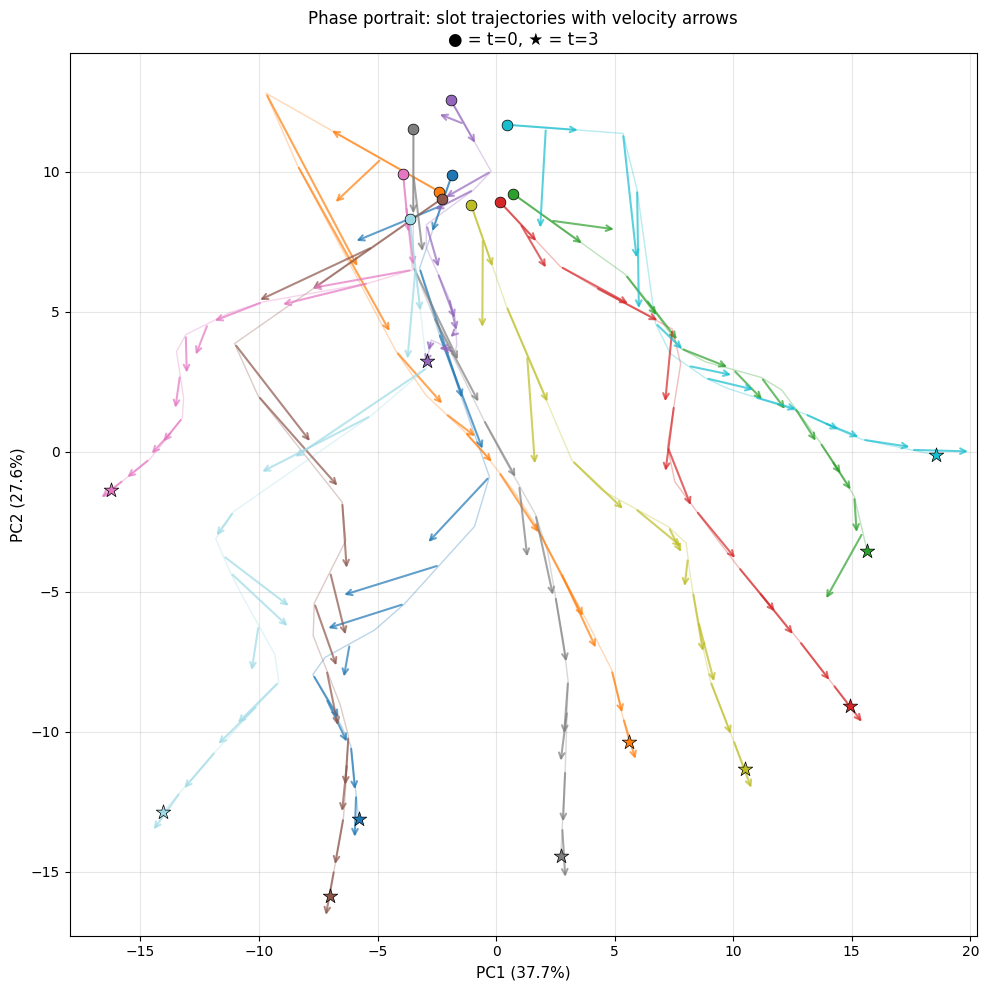

In [21]:
IMG_IDX = 0
traj_img = traj_np[:, IMG_IDX, :, :]  # [T, N_slots, D]

# fit PCA on trajectory points
all_pts = traj_img.reshape(-1, traj_img.shape[-1])
pca_vf = PCA(n_components=2)
pca_vf.fit(all_pts)

# compute velocity at trajectory points and project
n_arrow_pts = 12
arrow_indices = np.linspace(0, T_pts - 2, n_arrow_pts, dtype=int)

fig, ax = plt.subplots(figsize=(10, 10))

for s in range(N_slots):
    traj_s_2d = pca_vf.transform(traj_img[:, s, :])
    ax.plot(traj_s_2d[:, 0], traj_s_2d[:, 1], color=slot_colors[s], alpha=0.3, linewidth=1)
    ax.scatter(traj_s_2d[0, 0], traj_s_2d[0, 1], color=slot_colors[s], marker="o", s=60,
              edgecolors="black", linewidths=0.5, zorder=5)
    ax.scatter(traj_s_2d[-1, 0], traj_s_2d[-1, 1], color=slot_colors[s], marker="*", s=120,
              edgecolors="black", linewidths=0.5, zorder=5)

    for ti in arrow_indices:
        t_val = time_values[ti]
        slots_at_t = jnp.array(traj_np[ti, IMG_IDX:IMG_IDX+1])  # [1, N_slots, D]
        vel = np.array(ode_func(t_val, slots_at_t, (k_single, v_single)))  # [1, N_slots, D]
        vel_s = vel[0, s]  # [D]

        pos_2d = traj_s_2d[ti]
        vel_2d = pca_vf.transform(vel_s.reshape(1, -1))[0] - pca_vf.transform(np.zeros((1, vel_s.shape[0])))[0]

        scale = 0.3
        ax.annotate("", xy=pos_2d + scale * vel_2d, xytext=pos_2d,
                    arrowprops=dict(arrowstyle="->", color=slot_colors[s], lw=1.5, alpha=0.7))

ax.set_xlabel(f"PC1 ({pca_vf.explained_variance_ratio_[0]:.1%})", fontsize=11)
ax.set_ylabel(f"PC2 ({pca_vf.explained_variance_ratio_[1]:.1%})", fontsize=11)
ax.set_title(f"Phase portrait: slot trajectories with velocity arrows\n● = t=0, ★ = t={T_show:.0f}", fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Test-time generalization to different T

Locatello et al. (2020) show that vanilla Slot Attention (trained with T=3) **improves** with more
iterations at test time (Figure 2), because the shared-weight GRU iterates toward a fixed point.

Here we test whether the **autonomous** SlotODE generalizes similarly.
Since the vector field f(slots) is independent of time (fixed weights, no hypernetwork),
the system is a genuine autonomous ODE. This means:
- Running beyond training T should **not** degrade performance (unlike the time-dependent model).
- If the fixed point is stable, the reconstruction should **plateau** rather than diverge.
- This is exactly the Deep Equilibrium Model (DEQ) regime: iterate until convergence.

In [22]:
T_TEST_VALUES = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
IMG_IDX = 0
single_img = images_jax[IMG_IDX:IMG_IDX+1]

sa = model.slot_attention_ode

enc_feat_s = model.enc(single_img)
feat_norm_s = jax.vmap(jax.vmap(sa.norm_input))(enc_feat_s)
feat_s = jax.vmap(jax.vmap(sa.fc_input))(feat_norm_s)
k_s = jax.vmap(jax.vmap(sa.to_k))(feat_s)
v_s = jax.vmap(jax.vmap(sa.to_v))(feat_s)

ref_key = jax.random.key(42)
slots_0 = sa.initialize_slots(1, ref_key)

results_by_T = {}
for T_test in T_TEST_VALUES:
    term = diffrax.ODETerm(sa.slot_ode_func)
    solver = diffrax.Euler()
    sol = diffrax.diffeqsolve(
        term, solver, t0=0.0, t1=T_test, dt0=sa.dt0,
        y0=slots_0, args=(k_s, v_s),
        saveat=diffrax.SaveAt(t1=True),
        stepsize_controller=diffrax.ConstantStepSize(),
        max_steps=512,
    )
    slots_T = sol.ys[0]  # [1, N_slots, D]
    recon_T, masks_T = model.dec(slots_T)

    mse = float(jnp.mean((recon_T - single_img) ** 2))
    results_by_T[T_test] = {
        "slots": np.array(slots_T),
        "recon": np.array(recon_T),
        "masks": np.array(masks_T),
        "mse": mse,
    }
    print(f"T={T_test:.1f}: MSE={mse:.6f}")

print(f"\nTrained with T={T_show:.0f}")

T=1.0: MSE=0.016625


T=2.0: MSE=0.005415


T=3.0: MSE=0.000554


T=4.0: MSE=0.000779


T=5.0: MSE=0.002044


T=6.0: MSE=0.004826


T=7.0: MSE=0.008722


T=8.0: MSE=0.012755


T=9.0: MSE=0.017526


T=10.0: MSE=0.022721

Trained with T=3


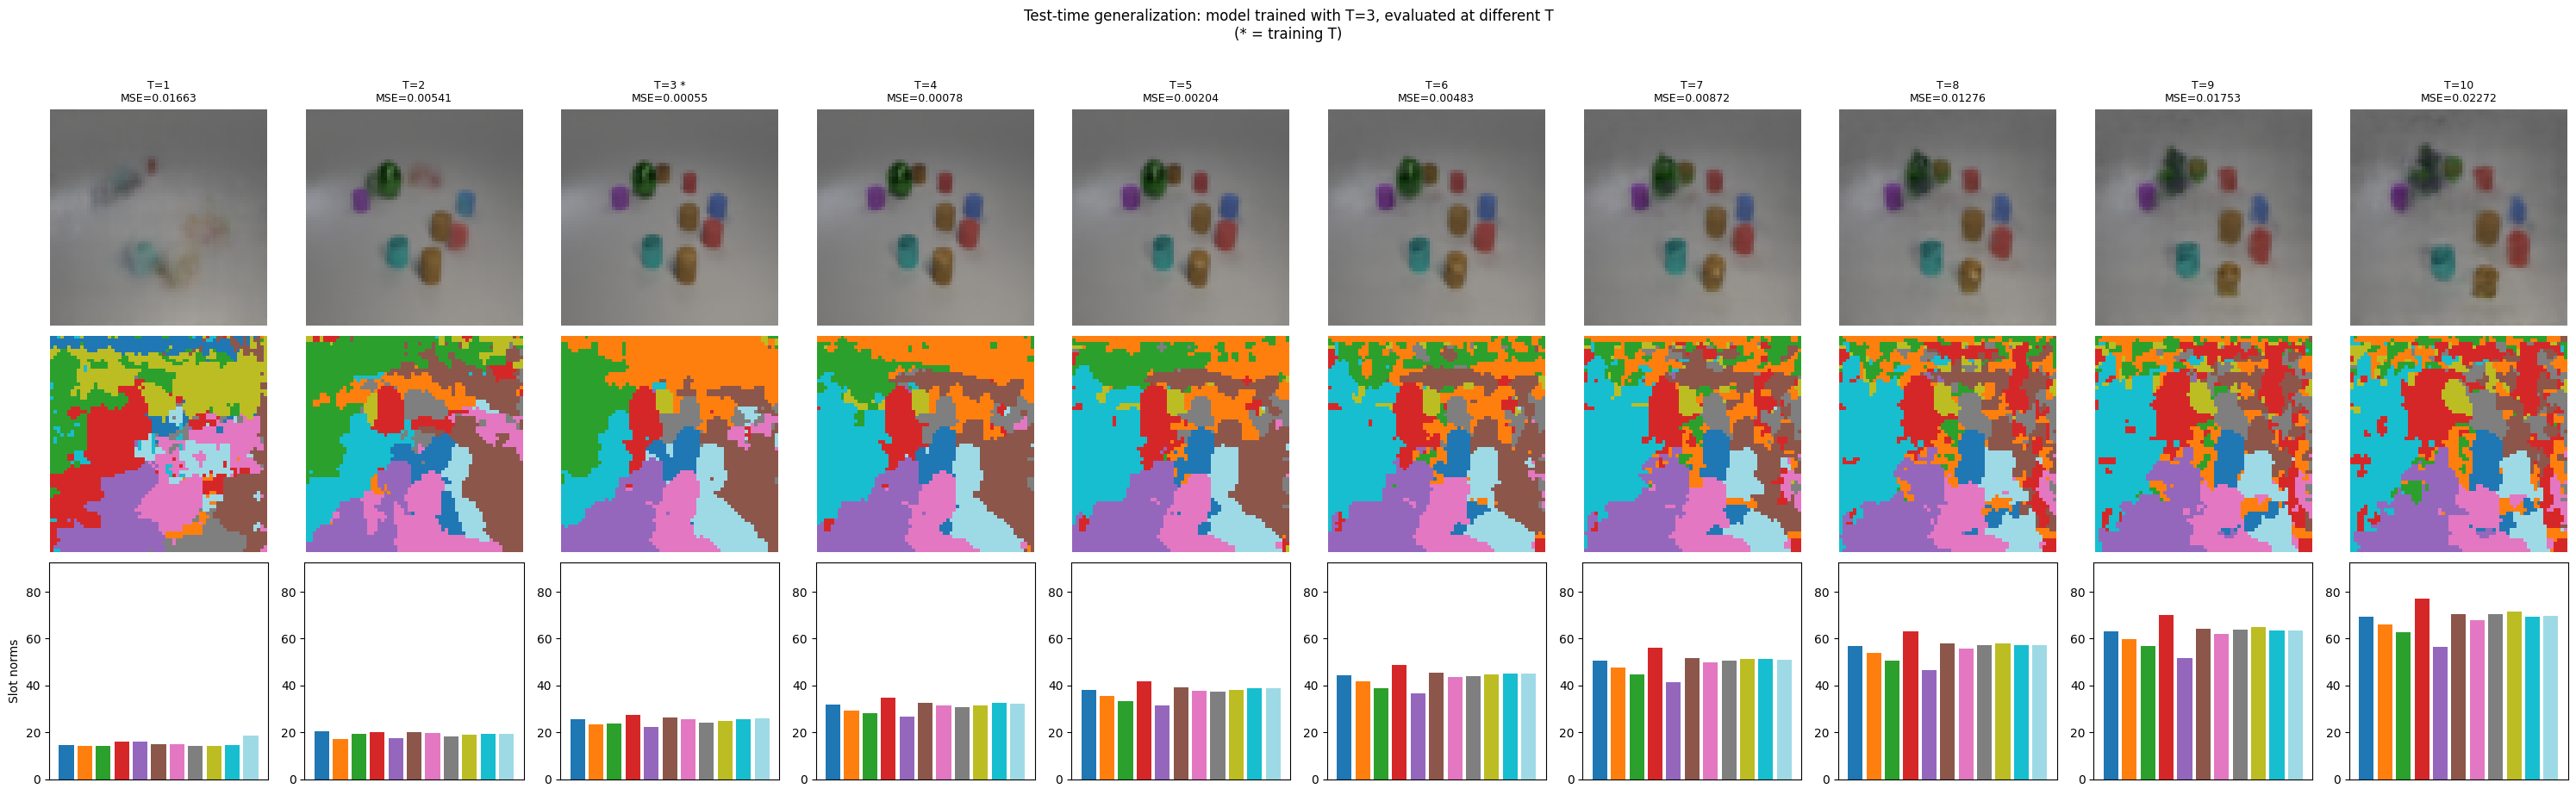

In [23]:
n_T = len(T_TEST_VALUES)
fig, axes = plt.subplots(3, n_T, figsize=(3 * n_T, 9))

for col, T_test in enumerate(T_TEST_VALUES):
    r = results_by_T[T_test]

    axes[0, col].imshow(to_img(r["recon"][0]))
    trained_marker = " *" if T_test == T_show else ""
    axes[0, col].set_title(f"T={T_test:.0f}{trained_marker}\nMSE={r['mse']:.5f}", fontsize=9)
    axes[0, col].axis("off")

    seg = r["masks"][0].argmax(axis=0)
    seg_rgb = np.zeros((*seg.shape, 3))
    for s in range(N_slots):
        seg_rgb[seg == s] = slot_colors[s]
    axes[1, col].imshow(seg_rgb)
    axes[1, col].axis("off")

    slot_norms = np.linalg.norm(r["slots"][0], axis=-1)  # [N_slots]
    axes[2, col].bar(range(N_slots), slot_norms, color=[slot_colors[s] for s in range(N_slots)])
    axes[2, col].set_ylim(0, max(slot_norms.max() * 1.2 for r in results_by_T.values()
                                  for slot_norms in [np.linalg.norm(r["slots"][0], axis=-1)]))
    if col == 0:
        axes[2, col].set_ylabel("‖slot‖", fontsize=10)
    axes[2, col].set_xticks([])

axes[0, 0].set_ylabel("Reconstruction", fontsize=10)
axes[1, 0].set_ylabel("Segmentation", fontsize=10)
axes[2, 0].set_ylabel("Slot norms", fontsize=10)

fig.suptitle(f"Test-time generalization: model trained with T={T_show:.0f}, evaluated at different T\n"
             f"(* = training T)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

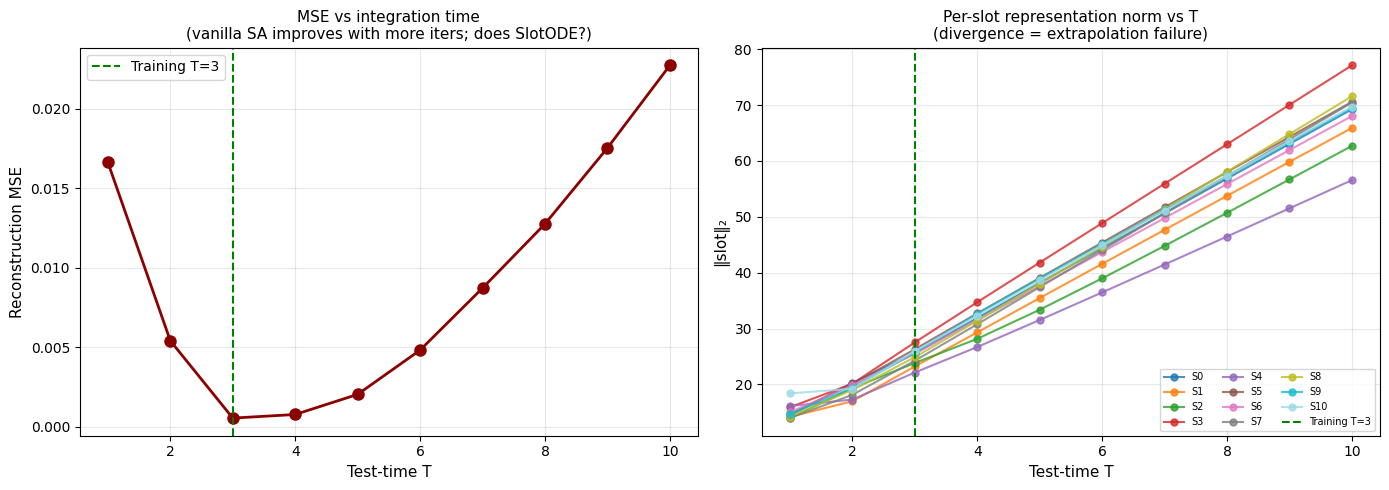

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mses = [results_by_T[T]["mse"] for T in T_TEST_VALUES]

ax = axes[0]
ax.plot(T_TEST_VALUES, mses, "o-", linewidth=2, markersize=8, color="darkred")
ax.axvline(T_show, color="green", linewidth=1.5, linestyle="--", label=f"Training T={T_show:.0f}")
ax.set_xlabel("Test-time T", fontsize=11)
ax.set_ylabel("Reconstruction MSE", fontsize=11)
ax.set_title("MSE vs integration time\n(vanilla SA improves with more iters; does SlotODE?)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# slot norm divergence
ax = axes[1]
for s in range(N_slots):
    norms = [np.linalg.norm(results_by_T[T]["slots"][0, s]) for T in T_TEST_VALUES]
    label = f"S{s}" if slot_activity[s] > 0.15 else None
    alpha = 0.8 if slot_activity[s] > 0.15 else 0.2
    ax.plot(T_TEST_VALUES, norms, "o-", color=slot_colors[s], alpha=alpha, linewidth=1.5,
            markersize=5, label=label)
ax.axvline(T_show, color="green", linewidth=1.5, linestyle="--", label=f"Training T={T_show:.0f}")
ax.set_xlabel("Test-time T", fontsize=11)
ax.set_ylabel("‖slot‖₂", fontsize=11)
ax.set_title("Per-slot representation norm vs T\n(divergence = extrapolation failure)", fontsize=11)
ax.legend(fontsize=7, ncol=3)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 14. Adaptive test-time compute: Dopri5 NFEs vs scene complexity

Since the autonomous ODE defines a **solver-independent** vector field, we can swap
the Euler integrator for adaptive Dopri5 at test time without retraining.

Key hypothesis: **harder scenes (more objects) should require more NFEs** under Dopri5,
because the slot dynamics are stiffer when more objects compete for attention.
This would demonstrate genuine *adaptive computation depth* — the model automatically
allocates more compute to harder inputs, a property impossible with fixed-step Euler.

In [11]:
N_SAMPLES_DOPRI = 200
DOPRI_TOL = 1e-3

sa = model.slot_attention_ode
T_train = float(sa.T)
term = diffrax.ODETerm(sa.slot_ode_func)

val_dir = Path("CLEVR_64/images/val")
vis_dir = Path("CLEVR_64/visibility/val")

all_imgs_sorted = sorted(val_dir.glob("*.png"))[:N_SAMPLES_DOPRI]
results = []

for img_path in all_imgs_sorted:
    stem = img_path.stem
    vis_path = vis_dir / f"{stem}.npy"
    visibility = np.load(vis_path)
    n_objects = int((visibility[1:] > 0.5).sum())

    img_pil = Image.open(img_path).convert("RGB")
    img_np = np.array(img_pil).astype(np.float32) / 255.0
    img_np = img_np * 2.0 - 1.0
    img_jax = jnp.array(img_np.transpose(2, 0, 1))[None]  # [1, 3, H, W]

    enc_feat_i = model.enc(img_jax)
    feat_norm_i = jax.vmap(jax.vmap(sa.norm_input))(enc_feat_i)
    feat_i = jax.vmap(jax.vmap(sa.fc_input))(feat_norm_i)
    k_i = jax.vmap(jax.vmap(sa.to_k))(feat_i)
    v_i = jax.vmap(jax.vmap(sa.to_v))(feat_i)

    key_i = jax.random.key(42)
    slots_0 = sa.initialize_slots(1, key_i)

    # Euler baseline
    euler_sol = diffrax.diffeqsolve(
        term, diffrax.Euler(), t0=0.0, t1=T_train, dt0=sa.dt0,
        y0=slots_0, args=(k_i, v_i),
        saveat=diffrax.SaveAt(t1=True),
        stepsize_controller=diffrax.ConstantStepSize(), max_steps=512,
    )
    slots_euler = euler_sol.ys[0]
    recon_euler, _ = model.dec(slots_euler)
    mse_euler = float(jnp.mean((recon_euler - img_jax) ** 2))

    # Dopri5 adaptive
    dopri_sol = diffrax.diffeqsolve(
        term, diffrax.Dopri5(), t0=0.0, t1=T_train, dt0=sa.dt0,
        y0=slots_0, args=(k_i, v_i),
        saveat=diffrax.SaveAt(t1=True),
        stepsize_controller=diffrax.PIDController(rtol=DOPRI_TOL, atol=DOPRI_TOL),
        max_steps=4096,
    )
    slots_dopri = dopri_sol.ys[0]
    recon_dopri, _ = model.dec(slots_dopri)
    mse_dopri = float(jnp.mean((recon_dopri - img_jax) ** 2))
    nfe_dopri = int(dopri_sol.stats['num_steps'])

    results.append({
        "stem": stem,
        "n_objects": n_objects,
        "mse_euler": mse_euler,
        "mse_dopri": mse_dopri,
        "nfe_dopri": nfe_dopri,
    })

nfe_euler_fixed = int(T_train / sa.dt0)
print(f"Evaluated {len(results)} images | Euler NFEs (fixed): {nfe_euler_fixed}")
print(f"Dopri5 tol={DOPRI_TOL:.0e} | NFE range: {min(r['nfe_dopri'] for r in results)}-{max(r['nfe_dopri'] for r in results)}")

Evaluated 200 images | Euler NFEs (fixed): 6
Dopri5 tol=1e-03 | NFE range: 9-22


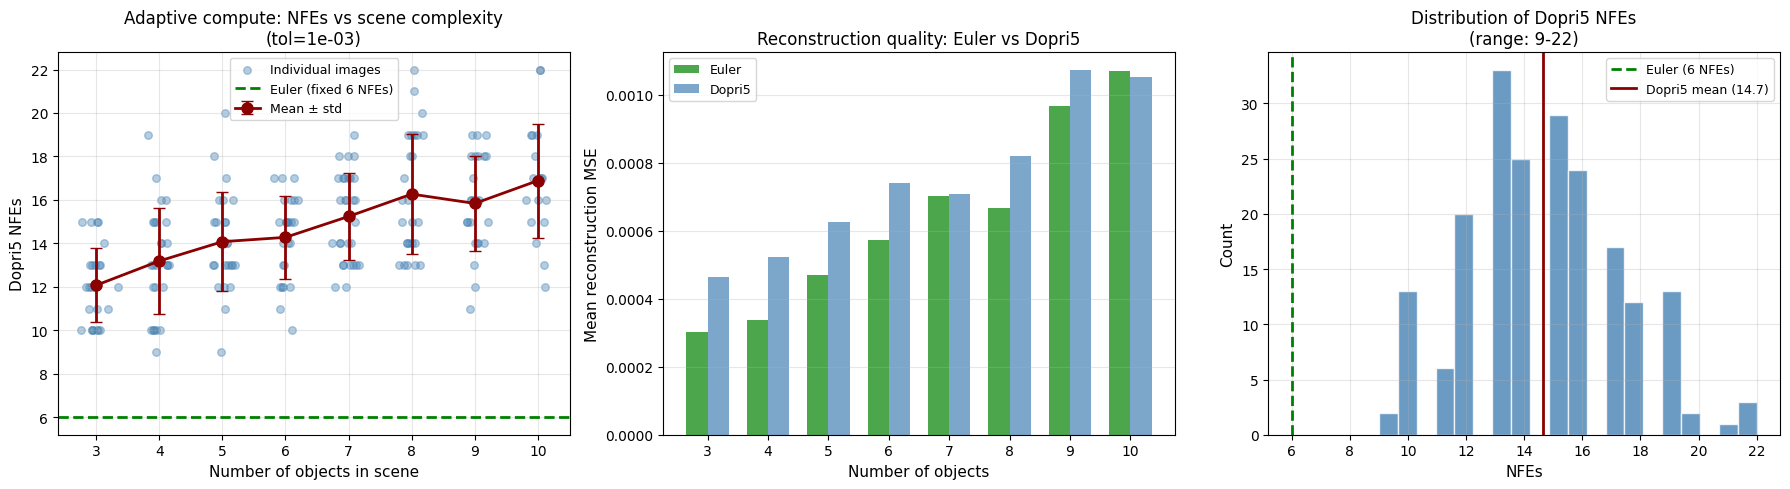


Correlation(n_objects, NFEs): r=0.539, p=0.0000
Euler fixed NFEs: 6
Dopri5 mean NFEs: 14.7 ± 2.7
Dopri5 MSE mean: 0.000737 vs Euler MSE mean: 0.000620
  3 objects (n=26): Dopri5 NFEs=12.1±1.7, MSE euler=0.000303, MSE dopri=0.000465
  4 objects (n=26): Dopri5 NFEs=13.2±2.4, MSE euler=0.000337, MSE dopri=0.000522
  5 objects (n=25): Dopri5 NFEs=14.1±2.3, MSE euler=0.000471, MSE dopri=0.000626
  6 objects (n=25): Dopri5 NFEs=14.3±1.9, MSE euler=0.000572, MSE dopri=0.000739
  7 objects (n=29): Dopri5 NFEs=15.2±2.0, MSE euler=0.000702, MSE dopri=0.000709
  8 objects (n=26): Dopri5 NFEs=16.3±2.8, MSE euler=0.000667, MSE dopri=0.000821
  9 objects (n=25): Dopri5 NFEs=15.8±2.2, MSE euler=0.000968, MSE dopri=0.001072
  10 objects (n=18): Dopri5 NFEs=16.9±2.6, MSE euler=0.001070, MSE dopri=0.001051


In [12]:
n_objs = np.array([r["n_objects"] for r in results])
nfes = np.array([r["nfe_dopri"] for r in results])
mse_euler_arr = np.array([r["mse_euler"] for r in results])
mse_dopri_arr = np.array([r["mse_dopri"] for r in results])

obj_counts = sorted(set(n_objs))
mean_nfe_by_obj = [nfes[n_objs == c].mean() for c in obj_counts]
std_nfe_by_obj = [nfes[n_objs == c].std() for c in obj_counts]
count_by_obj = [int((n_objs == c).sum()) for c in obj_counts]
mean_mse_euler_by_obj = [mse_euler_arr[n_objs == c].mean() for c in obj_counts]
mean_mse_dopri_by_obj = [mse_dopri_arr[n_objs == c].mean() for c in obj_counts]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel 1: NFEs vs number of objects ---
ax = axes[0]
ax.scatter(n_objs + np.random.randn(len(n_objs)) * 0.1, nfes,
           s=30, alpha=0.4, color="steelblue", label="Individual images")
ax.errorbar(obj_counts, mean_nfe_by_obj, yerr=std_nfe_by_obj,
            fmt="o-", color="darkred", linewidth=2, markersize=8, capsize=4,
            label="Mean ± std")
ax.axhline(nfe_euler_fixed, color="green", linestyle="--", linewidth=2,
           label=f"Euler (fixed {nfe_euler_fixed} NFEs)")
ax.set_xlabel("Number of objects in scene", fontsize=11)
ax.set_ylabel("Dopri5 NFEs", fontsize=11)
ax.set_title(f"Adaptive compute: NFEs vs scene complexity\n(tol={DOPRI_TOL:.0e})", fontsize=12)
ax.legend(fontsize=9)
ax.set_xticks(obj_counts)
ax.grid(True, alpha=0.3)

# --- Panel 2: MSE comparison by object count ---
ax = axes[1]
x_pos = np.arange(len(obj_counts))
width = 0.35
ax.bar(x_pos - width/2, mean_mse_euler_by_obj, width, label="Euler", color="green", alpha=0.7)
ax.bar(x_pos + width/2, mean_mse_dopri_by_obj, width, label="Dopri5", color="steelblue", alpha=0.7)
ax.set_xlabel("Number of objects", fontsize=11)
ax.set_ylabel("Mean reconstruction MSE", fontsize=11)
ax.set_title("Reconstruction quality: Euler vs Dopri5", fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(obj_counts)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="y")

# --- Panel 3: NFE histogram ---
ax = axes[2]
ax.hist(nfes, bins=20, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(nfe_euler_fixed, color="green", linestyle="--", linewidth=2,
           label=f"Euler ({nfe_euler_fixed} NFEs)")
ax.axvline(nfes.mean(), color="darkred", linestyle="-", linewidth=2,
           label=f"Dopri5 mean ({nfes.mean():.1f})")
ax.set_xlabel("NFEs", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title(f"Distribution of Dopri5 NFEs\n(range: {nfes.min()}-{nfes.max()})", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
from scipy import stats as sp_stats
corr, pval = sp_stats.pearsonr(n_objs, nfes)
print(f"\nCorrelation(n_objects, NFEs): r={corr:.3f}, p={pval:.4f}")
print(f"Euler fixed NFEs: {nfe_euler_fixed}")
print(f"Dopri5 mean NFEs: {nfes.mean():.1f} ± {nfes.std():.1f}")
print(f"Dopri5 MSE mean: {mse_dopri_arr.mean():.6f} vs Euler MSE mean: {mse_euler_arr.mean():.6f}")
for c in obj_counts:
    mask = n_objs == c
    print(f"  {c} objects (n={mask.sum()}): Dopri5 NFEs={nfes[mask].mean():.1f}±{nfes[mask].std():.1f}, "
          f"MSE euler={mse_euler_arr[mask].mean():.6f}, MSE dopri={mse_dopri_arr[mask].mean():.6f}")

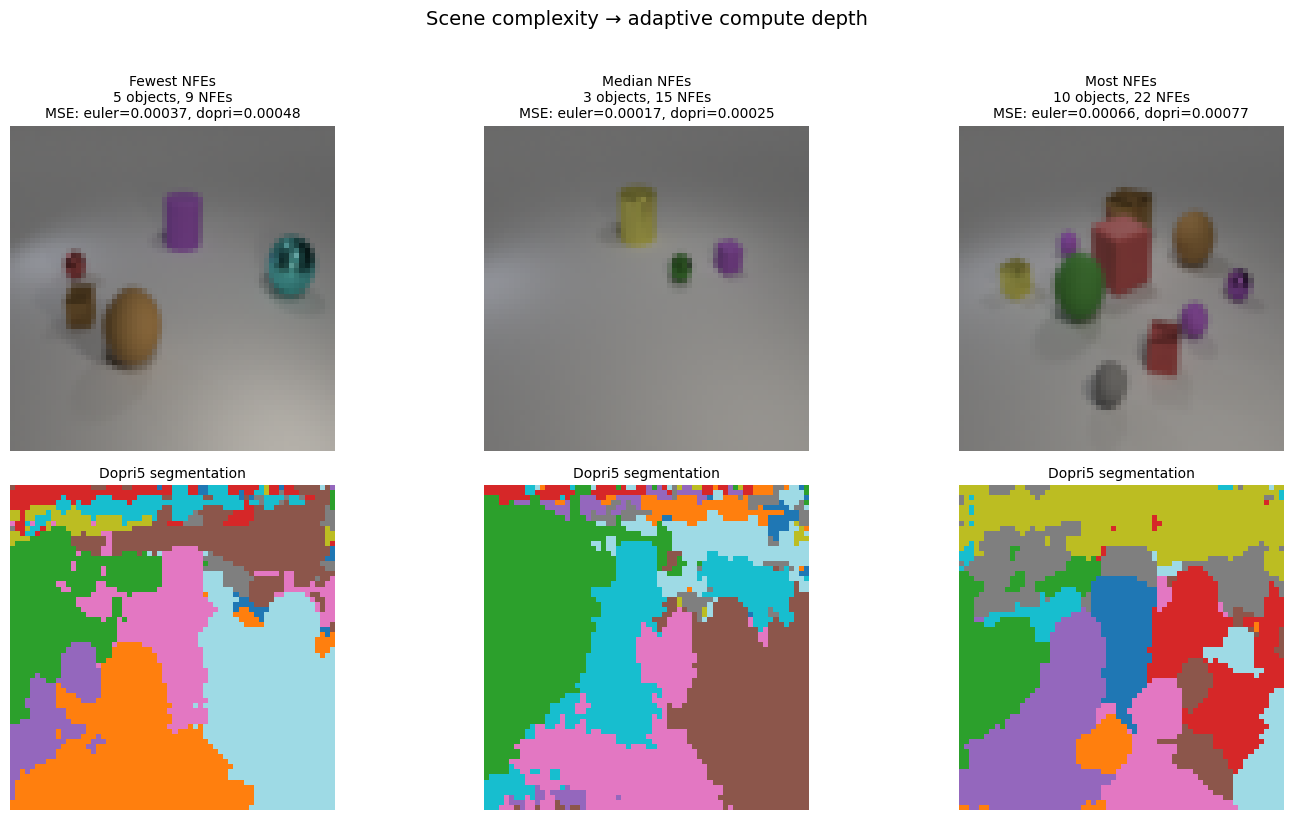

In [13]:
# Show example images: lowest NFE vs highest NFE
sorted_by_nfe = sorted(results, key=lambda r: r["nfe_dopri"])
examples = [sorted_by_nfe[0], sorted_by_nfe[len(sorted_by_nfe)//2], sorted_by_nfe[-1]]
labels = ["Fewest NFEs", "Median NFEs", "Most NFEs"]

fig, axes = plt.subplots(2, len(examples), figsize=(5 * len(examples), 8))

for col, (ex, label) in enumerate(zip(examples, labels)):
    img_path = val_dir / f"{ex['stem']}.png"
    img_pil = Image.open(img_path).convert("RGB")
    img_np = np.array(img_pil).astype(np.float32) / 255.0

    axes[0, col].imshow(img_np)
    axes[0, col].set_title(f"{label}\n{ex['n_objects']} objects, {ex['nfe_dopri']} NFEs\n"
                           f"MSE: euler={ex['mse_euler']:.5f}, dopri={ex['mse_dopri']:.5f}",
                           fontsize=10)
    axes[0, col].axis("off")

    # Run Dopri5 to get masks for this image
    img_jax_ex = jnp.array((img_np * 2.0 - 1.0).transpose(2, 0, 1))[None]
    enc_ex = model.enc(img_jax_ex)
    fn_ex = jax.vmap(jax.vmap(sa.norm_input))(enc_ex)
    ft_ex = jax.vmap(jax.vmap(sa.fc_input))(fn_ex)
    k_ex = jax.vmap(jax.vmap(sa.to_k))(ft_ex)
    v_ex = jax.vmap(jax.vmap(sa.to_v))(ft_ex)
    slots_0_ex = sa.initialize_slots(1, jax.random.key(42))

    sol_ex = diffrax.diffeqsolve(
        term, diffrax.Dopri5(), t0=0.0, t1=T_train, dt0=sa.dt0,
        y0=slots_0_ex, args=(k_ex, v_ex),
        saveat=diffrax.SaveAt(t1=True),
        stepsize_controller=diffrax.PIDController(rtol=DOPRI_TOL, atol=DOPRI_TOL),
        max_steps=4096,
    )
    _, masks_ex = model.dec(sol_ex.ys[0])
    seg_ex = np.array(masks_ex[0]).argmax(axis=0)

    axes[1, col].imshow(seg_ex, cmap="tab20", interpolation="nearest")
    axes[1, col].set_title("Dopri5 segmentation", fontsize=10)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Input", fontsize=12)
axes[1, 0].set_ylabel("Segmentation", fontsize=12)
fig.suptitle("Scene complexity → adaptive compute depth", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()